# ARIMA - SARIMA

## 1. Cài đặt và import thư viện

Cài đặt `pmdarima` nếu môi trường hiện tại chưa có thư viện này.

In [82]:
pip install -q pmdarima

Note: you may need to restart the kernel to use updated packages.


In [83]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm

from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller

warnings.filterwarnings("ignore")


In [84]:
# Config cho việc visualization

GREEN      = "#344f1e"
BLUE       = "#2f6f9f"
RED        = "#b5432f"
GRAY       = "#5f6b5d"
LIGHT_GREEN = "#eef4e8"
DARK = "#111827"
ORANGE = "#F59E0B"


plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.titlesize": 15,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
})

## 2. Chuẩn bị và chia dữ liệu

Ta nạp dữ liệu PM2.5 theo chu kỳ 6 giờ (6H), chia train/test theo mốc thời gian đã định.

In [85]:
train = pd.read_csv("/kaggle/input/datasets/binhdanghai/data-6h/PM25_2026_Q1_train_6h.csv")
test = pd.read_csv("/kaggle/input/datasets/binhdanghai/data-6h/PM25_2026_Q1_test_6h.csv")

train['Local Time'] = pd.to_datetime(train['Local Time'])
test['Local Time'] = pd.to_datetime(test['Local Time'])

# Chuyển DL về dạng series
train = pd.Series(
    train["PM25"].values,
    index=train["Local Time"],
    name="PM25" 
)

test = pd.Series(
    test["PM25"].values,
    index=test["Local Time"],
    name="PM25" 
)

# Chuyển về ngày
train = train.asfreq('6H')
test = test.asfreq('6H')

print(train.head().to_string())
print(f"Train: {train.index[0]} đến {train.index[-1]} ({len(train)} quan sát)")
print(f"Test:  {test.index[0]} đến {test.index[-1]} ({len(test)} quan sát)")

Local Time
2026-01-01 00:00:00    37.066667
2026-01-01 06:00:00    32.866667
2026-01-01 12:00:00    22.250000
2026-01-01 18:00:00    12.916667
2026-01-02 00:00:00    17.683333
Freq: 6h
Train: 2026-01-01 00:00:00 đến 2026-03-24 18:00:00 (332 quan sát)
Test:  2026-03-25 00:00:00 đến 2026-03-31 18:00:00 (28 quan sát)


## 3. Trực quan hóa tập huấn luyện

Trước khi mô hình hóa, ta quan sát chuỗi trên tập huấn luyện để nhận diện sơ bộ chu kỳ, biên độ dao động và các giai đoạn biến động mạnh.

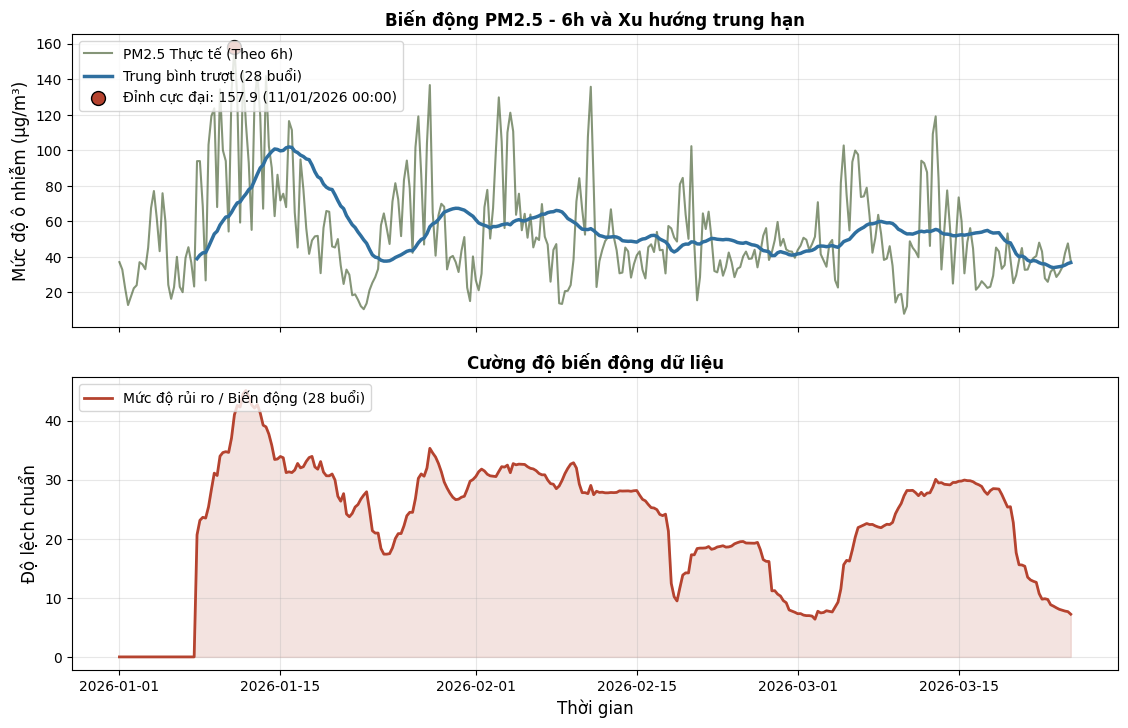

In [87]:
# ==========================================
# 1. TÍNH TOÁN BẰNG PANDAS (Nhanh và chính xác hơn Numpy thuần)
# ==========================================

# Thiết lập cửa sổ trượt: 28 đơn vị (Tương đương 7 ngày trong tuần vì dữ liệu đang là 6h)
window = 28 

# Dùng hàm .rolling() siêu cấp của Pandas
# min_periods=1 giúp tính toán ngay từ ngày đầu tiên thay vì bị NaN ở 6 ngày đầu
# rolling_mean = train.rolling(window=window, min_periods=1).mean()
# rolling_std  = train.rolling(window=window, min_periods=1).std()

rolling_mean = train.rolling(window=window).mean()
rolling_std  = train.rolling(window=window).std()

# Tìm giá trị và thời điểm đạt đỉnh ô nhiễm lớn nhất
peak_val = train.max()
peak_time = train.idxmax() # idxmax() lấy ra index (ngày) có giá trị max
peak_time_str = peak_time.strftime('%d/%m/%Y %H:00') # Format lại ngày cho đẹp

# ==========================================
# 2. VẼ ĐỒ THỊ
# ==========================================

fig, axes = plt.subplots(2, 1, figsize=(11.5, 7.5), sharex=True)

# --- Subplot 1: Giá trị PM2.5 và Trung bình trượt ---
ax = axes[0]
ax.plot(train.index, train.values, color=GREEN, linewidth=1.5, alpha=0.6, label="PM2.5 Thực tế (Theo 6h)")
ax.plot(train.index, rolling_mean, color=BLUE, linewidth=2.5, label=f"Trung bình trượt ({window} buổi)")

# Đánh dấu đỉnh cực đại
ax.scatter([peak_time], [peak_val], s=100, color=RED, zorder=5, edgecolors='black',
           label=f"Đỉnh cực đại: {peak_val:.1f} ({peak_time_str})")

ax.set_title("Biến động PM2.5 - 6h và Xu hướng trung hạn", fontsize=12, fontweight='bold')
ax.set_ylabel("Mức độ ô nhiễm (µg/m³)")
ax.legend(loc="upper left", ncol=1, frameon=True)
ax.grid(alpha=0.3)

# --- Subplot 2: Độ lệch chuẩn trượt ---
ax = axes[1]
# Xử lý trường hợp ngày đầu tiên std bị NaN (do không đủ 2 điểm để tính độ lệch)
rolling_std_clean = rolling_std.fillna(0) 

ax.plot(train.index, rolling_std_clean, color=RED, linewidth=2.0, label=f"Mức độ rủi ro / Biến động ({window} buổi)")
ax.fill_between(train.index, 0, rolling_std_clean, color=RED, alpha=0.15)

ax.set_title("Cường độ biến động dữ liệu", fontsize=12, fontweight='bold')
ax.set_xlabel("Thời gian")
ax.set_ylabel("Độ lệch chuẩn")
ax.legend(loc="upper left", frameon=True)
ax.grid(alpha=0.3)

fig.tight_layout(pad=1.5)
plt.show()

## 4. Kiểm tra tính dừng và chọn \(d\)

Ta dùng kiểm định Augmented Dickey–Fuller (ADF) cho chuỗi gốc và chuỗi sau sai phân bậc một.

In [88]:
raw_adf_stat, raw_p_value, *_ = adfuller(train)

diff_train = train.diff().dropna()
diff_adf_stat, diff_p_value, *_ = adfuller(diff_train)

log_train = np.log(train.replace(0, np.nan)).dropna()
log_adf_stat, log_p_value, *_ = adfuller(log_train)

diff_log_train = log_train.diff().dropna()
diff_log_adf_stat, diff_log_p_value, *_ = adfuller(diff_log_train)

print(f"ADF statistic train series: {raw_adf_stat:.4f}")
print(f"ADF p-value train series: {raw_p_value:.4f}")
print(f"ADF statistic first difference: {diff_adf_stat:.4f}")
print(f"ADF p-value first difference: {diff_p_value:.4e}")
print(f"ADF statistic log-transformed: {log_adf_stat:.4f}")
print(f"ADF p-value log-transformed: {log_p_value:.4e}")
print(f"ADF statistic log-differenced: {diff_log_adf_stat:.4f}")
print(f"ADF p-value log-differenced: {diff_log_p_value:.4e}")

ADF statistic train series: -4.7378
ADF p-value train series: 0.0001
ADF statistic first difference: -7.0458
ADF p-value first difference: 5.6901e-10
ADF statistic log-transformed: -4.2902
ADF p-value log-transformed: 4.6196e-04
ADF statistic log-differenced: -6.6855
ADF p-value log-differenced: 4.2369e-09


Nếu chuỗi gốc chưa dừng nhưng chuỗi sai phân bậc một dừng, ta chọn \(d=1\).

Nhưng chuỗi gốc đã dừng

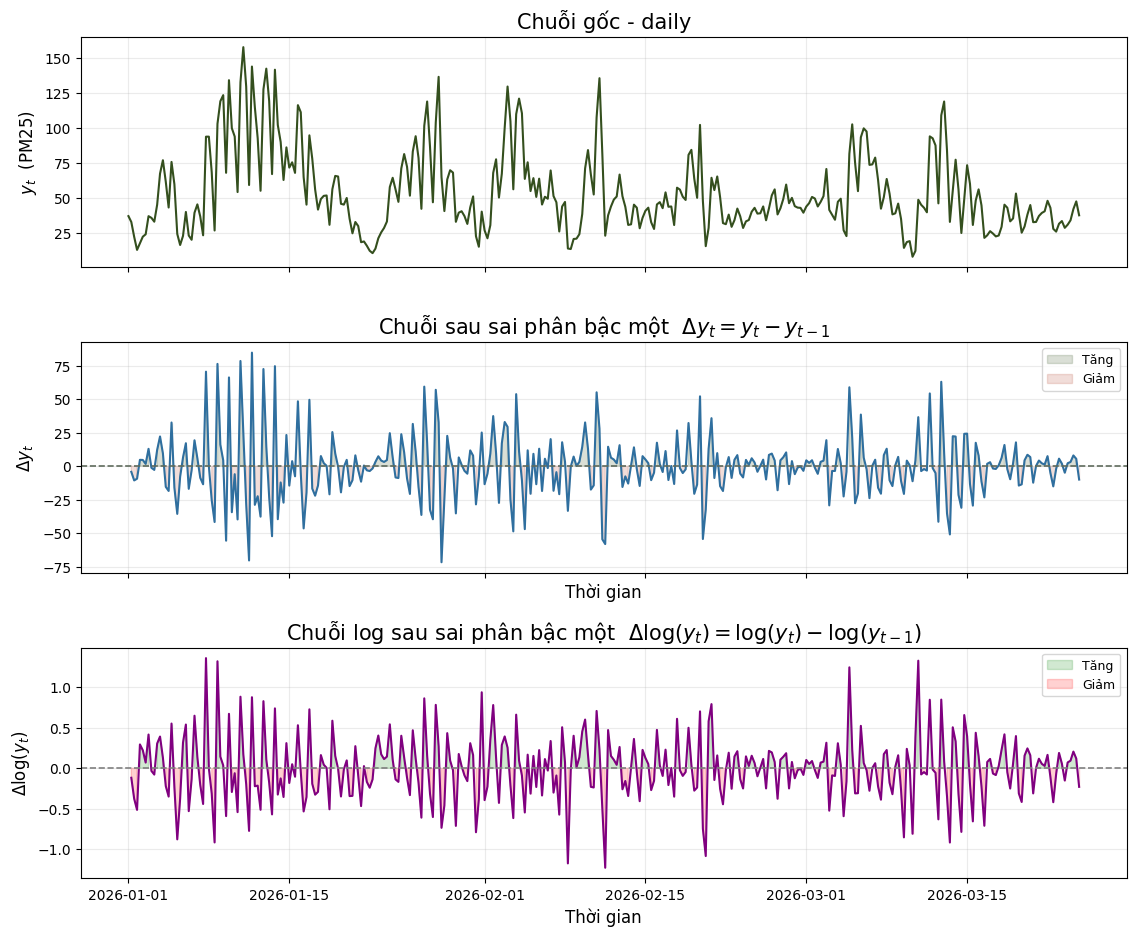

In [90]:
dy = np.diff(y)

y_log = np.log1p(np.asarray(y, dtype=float)) 
dy_log = np.diff(y_log)

t_diff = t[1:]
fig, axes = plt.subplots(3, 1, figsize=(11.5, 9.5), sharex=True)

# Ensure arrays align and contain no NaN/inf (needed for fill_between)
t_np = np.asarray(t)
y_np = np.asarray(y, dtype=float)
td_np = np.asarray(t_diff)
dy_np = np.asarray(dy, dtype=float)
dy_log_np = np.asarray(dy_log, dtype=float) # Biến mới cho chuỗi log

n = min(len(td_np), len(dy_np))
td_np = td_np[:n]
dy_np = dy_np[:n]
dy_log_np = dy_log_np[:n]

# Điều kiện hợp lệ cho fill_between không bị lỗi
valid = np.isfinite(td_np) & np.isfinite(dy_np)
valid_log = np.isfinite(td_np) & np.isfinite(dy_log_np)

a0 = axes[0]
a0.plot(t_np, y_np, color=GREEN, linewidth=1.5)
a0.set_title("Chuỗi gốc - daily")
a0.set_ylabel(r"$y_t$  (PM25)")
a0.grid(alpha=0.25)

a1 = axes[1]
a1.plot(td_np[valid], dy_np[valid], color=BLUE, linewidth=1.5)
a1.axhline(0, color=GRAY, linewidth=1.2, linestyle="--")
a1.fill_between(td_np[valid], 0, dy_np[valid], where=(dy_np[valid] >= 0), color=GREEN, alpha=0.18, label="Tăng")
a1.fill_between(td_np[valid], 0, dy_np[valid], where=(dy_np[valid] <  0), color=RED,   alpha=0.18, label="Giảm")
a1.set_title(r"Chuỗi sau sai phân bậc một  $\Delta y_t = y_t - y_{t-1}$")
a1.set_ylabel(r"$\Delta y_t$")
a1.set_xlabel("Thời gian")
a1.legend(loc="upper right", frameon=True, fontsize=9)
a1.grid(alpha=0.25)

a2 = axes[2] # Sử dụng axes[2] cho đồ thị thứ 3
a2.plot(td_np[valid_log], dy_log_np[valid_log], color='purple', linewidth=1.5) # Đổi màu cho dễ phân biệt
a2.axhline(0, color='gray', linewidth=1.2, linestyle="--")
a2.fill_between(td_np[valid_log], 0, dy_log_np[valid_log], where=(dy_log_np[valid_log] >= 0), color='green', alpha=0.18, label="Tăng")
a2.fill_between(td_np[valid_log], 0, dy_log_np[valid_log], where=(dy_log_np[valid_log] <  0), color='red',   alpha=0.18, label="Giảm")
a2.set_title(r"Chuỗi log sau sai phân bậc một  $\Delta \log(y_t) = \log(y_t) - \log(y_{t-1})$")
a2.set_ylabel(r"$\Delta \log(y_t)$")
a2.set_xlabel("Thời gian")
a2.legend(loc="upper right", frameon=True, fontsize=9)
a2.grid(alpha=0.25)

fig.tight_layout(pad=1.2)
plt.show()


## 5. Nhận diện \(p,q\) bằng ACF/PACF

Ta quan sát ACF và PACF của chuỗi sai phân để xác định miền tìm kiếm ban đầu cho \(p\) và \(q\).

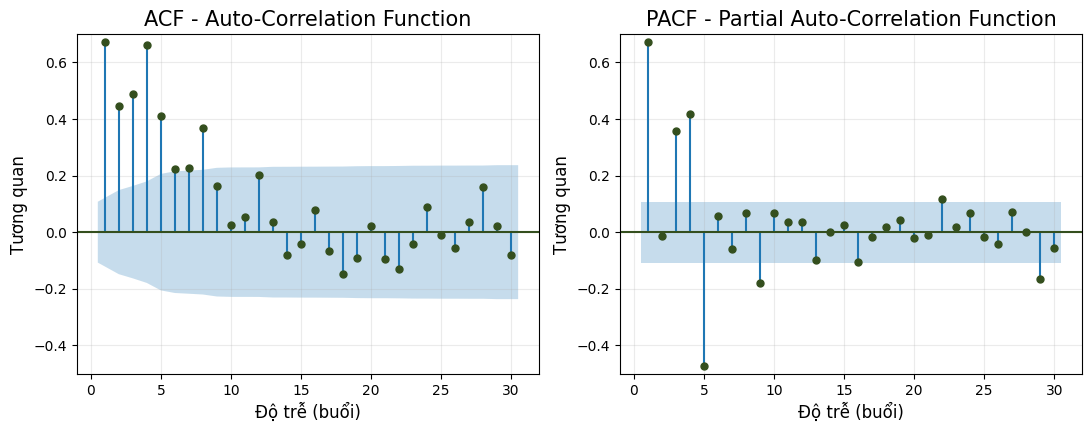

In [91]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ACF/PACF cần được quan sát
acf_input = train

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.4))

plot_acf(
    acf_input,
    ax=axes[0],
    lags=30,
    zero=False,
    alpha = 0.05,
    color=GREEN,
    title="ACF - Auto-Correlation Function"
)

plot_pacf(
    acf_input,
    ax=axes[1],
    lags=30,
    zero=False,
    color=GREEN,
    alpha = 0.05,
    method="ywm",
    title="PACF - Partial Auto-Correlation Function"
)

for ax in axes:
    ax.set_xlabel("Độ trễ (buổi)")
    ax.set_ylabel("Tương quan")
    ax.grid(alpha=0.25)

for ax in axes:
   ax.set_ylim(-0.5, 0.7)
    
fig.tight_layout(pad=1.0)
plt.show()

- ACF: Các cọc đâm vượt dải băng xanh rất nhiều (từ lag 1 đến lag 6, và lag 8). Tuy nhiên, thay vì giảm dần đều, tự nhiên đến lag 4 cọc lại cao vọt lên lại (đạt mức ~0.65) => tính mùa vụ cực kỳ mạnh theo chu kỳ 4 buổi. 
    - Đánh giá q: Cho phần phi mùa vụ (non-seasonal), đà giảm chậm đứt đoạn ở khoảng lag 1, 2, 3 => q có thể dao động từ 1 đến 3. 
    - Cho phần mùa vụ (seasonal), cọc lag 4 vọt lên => Q = 1.
    
- PACF: Cọc lag 1 dương rất cao, lag 2 tụt xuống gần 0, nhưng lag 3 và lag 4 lại đâm lên mạnh vượt dải xanh.Đặc biệt, có một cọc đâm ngược xuống cực sâu (âm) tại lag 5. Sự nhiễu loạn ở khu vực lag 4, 5 này là do sự giao thoa giữa quán tính của buổi trước đó và quán tính của cùng buổi ngày hôm qua.
    - Đánh giá p: Cho phần phi mùa vụ, cọc lag 1 mạnh nhất, sau đó có thể xem xét thêm lag 3 => p có thể là 1 hoặc 3. 

    - Cho phần mùa vụ, cọc lag 4 thể hiện rõ => P = 1.
    
Với đặc thù dữ liệu 6h/lần này, mô hình ARIMA(1, 0, 1) thuần túy sẽ "chết đứng" vì không thể bắt được nhịp đập 4 buổi/ngày. Bạn bắt buộc phải chuyển sang SARIMA. => Chu kỳ mùa vụ: s = 4

SARIMA(p, d, q)(P, D, Q)[s] cơ sở để chạy thử:
- SARIMA(1, 0, 1)(1, 0, 1)[4]
- (Bắt thêm lag trễ): SARIMA(3, 0, 1)(1, 0, 1)[4]
- (Nới rộng MA): SARIMA(1, 0, 2)(1, 0, 1)[4]

Lưu ý: Việc PACF có cọc âm rất sâu ở lag 5 cũng là dấu hiệu gợi ý bạn có thể phải dùng thêm biến ngoại sinh (ARIMAX) hoặc chuyển hẳn sang XGBoost/Random Forest kết hợp trễ (Lags) nếu mô hình thống kê SARIMA chạy ra kết quả lỗi vẫn còn tính tự tương quan.

## 6. Lựa chọn mô hình bằng AIC

Ta dùng `auto_arima` để tìm mô hình có AIC thấp nhất trong không gian tìm kiếm đã chỉ định.

không lấy log, lấy sai phân và chạy p, q

In [92]:
auto_model_aic = auto_arima(
    train,
    start_p=0,
    start_q=0,
    max_p=8,
    max_q=8,
    # D=1,
    # max_P=2,
    # max_Q=2,
    d=1,
    #m = 24,  # Chu kỳ mùa (24 giờ)
    seasonal=False,
    information_criterion="aic",
    trace=True,
    error_action="ignore",
    suppress_warnings=True,
    stepwise=False,
    max_order=None,
    with_intercept=False
)

selected_order = auto_model_aic.order

print("Best order by AIC:", selected_order)
print(f"Best AIC: {auto_model_aic.aic():.4f}")

 ARIMA(0,1,0)(0,0,0)[0]             : AIC=3030.311, Time=0.02 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=2986.950, Time=0.05 sec
 ARIMA(0,1,2)(0,0,0)[0]             : AIC=2959.866, Time=0.09 sec
 ARIMA(0,1,3)(0,0,0)[0]             : AIC=2943.843, Time=0.17 sec
 ARIMA(0,1,4)(0,0,0)[0]             : AIC=2882.109, Time=0.16 sec
 ARIMA(0,1,5)(0,0,0)[0]             : AIC=2875.590, Time=0.20 sec
 ARIMA(0,1,6)(0,0,0)[0]             : AIC=2862.957, Time=0.33 sec
 ARIMA(0,1,7)(0,0,0)[0]             : AIC=2852.516, Time=0.98 sec
 ARIMA(0,1,8)(0,0,0)[0]             : AIC=2844.294, Time=1.09 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=3024.704, Time=0.05 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=2973.493, Time=0.10 sec
 ARIMA(1,1,2)(0,0,0)[0]             : AIC=2961.816, Time=0.14 sec
 ARIMA(1,1,3)(0,0,0)[0]             : AIC=2888.584, Time=0.28 sec
 ARIMA(1,1,4)(0,0,0)[0]             : AIC=2881.161, Time=0.21 sec
 ARIMA(1,1,5)(0,0,0)[0]             : AIC=inf, Time=0.70 sec
 ARIMA(1,1,6)(0

### chạy p, q từ 0 đến 8

In [93]:
auto_model_aic = auto_arima(
    log_train,
    start_p=0,
    start_q=0,
    max_p=8,
    max_q=8,
    # D=1,
    # max_P=2,
    # max_Q=2,
    d=0,
    #m = 24,  # Chu kỳ mùa (24 giờ)
    seasonal=False,
    information_criterion="aic",
    trace=True,
    error_action="ignore",
    suppress_warnings=True,
    stepwise=False,
    max_order=None,
    with_intercept=False
)

selected_order = auto_model_aic.order

print("Best order by AIC:", selected_order)
print(f"Best AIC: {auto_model_aic.aic():.4f}")

 ARIMA(0,0,0)(0,0,0)[0]             : AIC=1846.137, Time=0.02 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=1459.351, Time=0.05 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=1095.931, Time=0.10 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=923.927, Time=0.21 sec
 ARIMA(0,0,4)(0,0,0)[0]             : AIC=775.853, Time=0.23 sec
 ARIMA(0,0,5)(0,0,0)[0]             : AIC=753.832, Time=0.34 sec
 ARIMA(0,0,6)(0,0,0)[0]             : AIC=594.626, Time=0.58 sec
 ARIMA(0,0,7)(0,0,0)[0]             : AIC=572.846, Time=0.46 sec
 ARIMA(0,0,8)(0,0,0)[0]             : AIC=535.895, Time=0.80 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=inf, Time=0.03 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=338.274, Time=0.15 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=306.488, Time=0.17 sec
 ARIMA(1,0,3)(0,0,0)[0]             : AIC=290.516, Time=0.27 sec
 ARIMA(1,0,4)(0,0,0)[0]             : AIC=248.006, Time=0.29 sec
 ARIMA(1,0,5)(0,0,0)[0]             : AIC=239.241, Time=0.39 sec
 ARIMA(1,0,6)(0,0,0)[0]   

### Chạy P, Q từ 0 - 2

In [94]:
auto_model_aic = auto_arima(
    log_train,
    start_p=0,
    start_q=0,
    max_p=5,
    max_q=5,
    D=1,
    start_P=0,
    start_Q=0,
    max_P=2,
    max_Q=2,
    d=0,
    m = 4, # Chu kỳ mùa: 4 buổi
    seasonal=True,
    information_criterion="aic",
    trace=True,
    error_action="ignore",
    suppress_warnings=True,
    stepwise=False,
    max_order=None,
    with_intercept=False
)

selected_order = auto_model_aic.order

print("Best order by AIC:", selected_order)
print(f"Best AIC: {auto_model_aic.aic():.4f}")

 ARIMA(0,0,0)(0,1,0)[4]             : AIC=462.349, Time=0.03 sec
 ARIMA(0,0,0)(0,1,1)[4]             : AIC=460.175, Time=0.06 sec
 ARIMA(0,0,0)(0,1,2)[4]             : AIC=inf, Time=0.25 sec
 ARIMA(0,0,0)(1,1,0)[4]             : AIC=462.394, Time=0.05 sec
 ARIMA(0,0,0)(1,1,1)[4]             : AIC=inf, Time=0.43 sec
 ARIMA(0,0,0)(1,1,2)[4]             : AIC=inf, Time=0.71 sec
 ARIMA(0,0,0)(2,1,0)[4]             : AIC=442.569, Time=0.08 sec
 ARIMA(0,0,0)(2,1,1)[4]             : AIC=inf, Time=0.70 sec
 ARIMA(0,0,0)(2,1,2)[4]             : AIC=inf, Time=1.02 sec
 ARIMA(0,0,1)(0,1,0)[4]             : AIC=254.112, Time=0.08 sec
 ARIMA(0,0,1)(0,1,1)[4]             : AIC=247.918, Time=0.12 sec
 ARIMA(0,0,1)(0,1,2)[4]             : AIC=207.198, Time=0.34 sec
 ARIMA(0,0,1)(1,1,0)[4]             : AIC=251.883, Time=0.11 sec
 ARIMA(0,0,1)(1,1,1)[4]             : AIC=inf, Time=0.63 sec
 ARIMA(0,0,1)(1,1,2)[4]             : AIC=inf, Time=0.79 sec
 ARIMA(0,0,1)(2,1,0)[4]             : AIC=239.694, Ti

In [95]:
selected_seasonal = auto_model_aic.seasonal_order # (P, D, Q, s)
print("-" * 30)
print(f"Best SARIMA order: {selected_order}")
print(f"Best Seasonal order: {selected_seasonal}")
print(f"Best AIC: {auto_model_aic.aic():.4f}")

------------------------------
Best SARIMA order: (3, 0, 0)
Best Seasonal order: (0, 1, 2, 4)
Best AIC: 138.8548


## 7. Huấn luyện mô hình SARIMA được chọn

Sau khi chọn được cấu hình tốt nhất theo AIC, ta ước lượng mô hình cuối cùng trên toàn bộ tập huấn luyện bằng `statsmodels`.

In [96]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [97]:
final_model = SARIMAX(
    train,
    order=selected_order,
    seasonal_order=selected_seasonal,
    trend="n",
    enforce_stationarity=False,
    enforce_invertibility=False
)
final_result = final_model.fit(disp=False)

p, d, q = selected_order
P, D, Q, m = selected_seasonal
model_label = f"SARIMA({p},{d},{q})({P},{D},{Q})[{m}]"

print(f"Mô hình được chọn: {model_label}")
print(final_result.summary())

Mô hình được chọn: SARIMA(3,0,0)(0,1,2)[4]
                                       SARIMAX Results                                        
Dep. Variable:                                   PM25   No. Observations:                  332
Model:             SARIMAX(3, 0, 0)x(0, 1, [1, 2], 4)   Log Likelihood               -1335.762
Date:                                Mon, 04 May 2026   AIC                           2683.524
Time:                                        17:58:27   BIC                           2706.115
Sample:                                    01-01-2026   HQIC                          2692.546
                                         - 03-24-2026                                         
Covariance Type:                                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.7795      0.049     15

## 8. Chẩn đoán phần dư

Ta kiểm tra phần dư bằng chuỗi phần dư theo thời gian, ACF phần dư và kiểm định Ljung–Box.

In [98]:
residuals = final_result.resid.dropna()

# Bậc tự do hiệu chỉnh = p + q + P + Q cho SARIMA
model_df = p + q + P + Q
max_lag  = 3 * 24  # 72 giờ

lb_lags = list(range(model_df + 1, max_lag + 1))
if not lb_lags:
    raise ValueError(f"model_df={model_df} >= max_lag={max_lag}, không còn lag hợp lệ.")

ljung_box_result = acorr_ljungbox(
    residuals, lags=lb_lags, model_df=model_df, return_df=True
)

print(f"Mô hình: {model_label}")
print(f"model_df = p+q+P+Q = {model_df}")
print(ljung_box_result.tail(10))

Mô hình: SARIMA(3,0,0)(0,1,2)[4]
model_df = p+q+P+Q = 5
      lb_stat  lb_pvalue
63  77.067697   0.047739
64  77.454838   0.053878
65  77.550010   0.063301
66  77.597695   0.074401
67  79.219761   0.069257
68  79.732522   0.075757
69  79.804424   0.087876
70  80.210150   0.096860
71  80.333824   0.110415
72  80.347533   0.126926


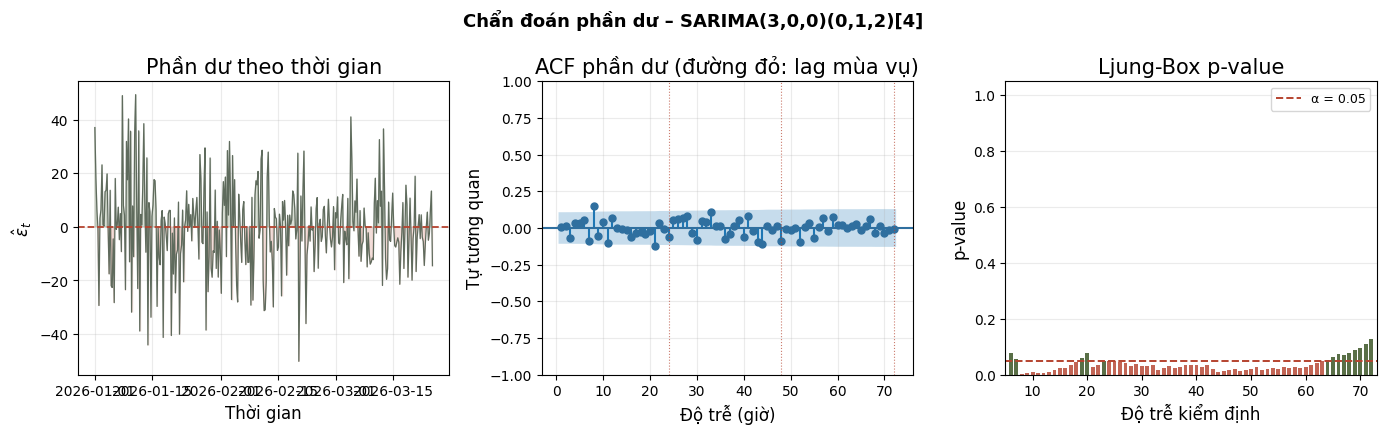

In [99]:
from statsmodels.graphics.tsaplots import plot_acf as sm_plot_acf

resid_values = residuals.to_numpy(dtype=float)
resid_time   = residuals.index
lags_full    = ljung_box_result.index.to_numpy()
pvals_full   = ljung_box_result["lb_pvalue"].to_numpy()

fig, axes = plt.subplots(1, 3, figsize=(14.0, 4.4))

# ── Chuỗi phần dư ────────────────────────────────────────────────────────
axes[0].plot(resid_time, resid_values, color=GRAY, linewidth=0.9)
axes[0].axhline(0, color=RED, linestyle="--", linewidth=1.3)
axes[0].fill_between(resid_time, 0, resid_values,
    where=(resid_values >= 0), color=GREEN, alpha=0.18)
axes[0].fill_between(resid_time, 0, resid_values,
    where=(resid_values <  0), color=RED,   alpha=0.18)
axes[0].set_title("Phần dư theo thời gian")
axes[0].set_xlabel("Thời gian")
axes[0].set_ylabel(r"$\hat{\varepsilon}_t$")
axes[0].grid(alpha=0.25)

# ── ACF phần dư ──────────────────────────────────────────────────────────
sm_plot_acf(residuals, ax=axes[1], lags=max_lag,
            zero=False, color=BLUE, alpha=0.05)
for lag_s in [24, 48, 72]:
    axes[1].axvline(lag_s, color=RED, linewidth=0.8, linestyle=":", alpha=0.7)
axes[1].set_title("ACF phần dư (đường đỏ: lag mùa vụ)")
axes[1].set_xlabel("Độ trễ (giờ)")
axes[1].set_ylabel("Tự tương quan")
axes[1].grid(alpha=0.25)

# ── Ljung-Box p-values ────────────────────────────────────────────────────
axes[2].bar(lags_full, pvals_full,
    color=[GREEN if p > 0.05 else RED for p in pvals_full],
    alpha=0.82, width=0.7)
axes[2].axhline(0.05, color=RED, linestyle="--", linewidth=1.4, label="α = 0.05")
axes[2].set_title("Ljung-Box p-value")
axes[2].set_xlabel("Độ trễ kiểm định")
axes[2].set_ylabel("p-value")
axes[2].set_xlim(model_df, max_lag + 1)
axes[2].set_ylim(0, 1.05)
axes[2].legend(frameon=True, fontsize=9)
axes[2].grid(axis="y", alpha=0.25)

fig.suptitle(f"Chẩn đoán phần dư – {model_label}", fontsize=13, fontweight="bold")
fig.tight_layout(pad=1.2)
plt.show()

## 9. Dự báo trên tập kiểm tra

Sau khi mô hình đạt yêu cầu ở bước chẩn đoán phần dư, ta dự báo trên tập kiểm tra và đánh giá sai số.

In [101]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Trích xuất chỉ cột chứa giá trị số (PM25) từ tập test
test_values = test['PM25'] if isinstance(test, pd.DataFrame) else test

n_steps         = len(test_values)
forecast_result = final_result.get_forecast(steps=n_steps)
sarima_forecast = forecast_result.predicted_mean
conf_int        = forecast_result.conf_int()

sarima_forecast.index = test_values.index
conf_int.index        = test_values.index

# ── Metrics ──────────────────────────────────────────────────────────────
# Truyền test_values (chỉ chứa số) vào các hàm tính toán
mae  = mean_absolute_error(test_values, sarima_forecast)
rmse = np.sqrt(mean_squared_error(test_values, sarima_forecast))
r2   = 1 - np.sum((test_values - sarima_forecast)**2) / np.sum((test_values - test_values.mean())**2)
wape = np.sum(np.abs(test_values - sarima_forecast)) / np.sum(np.abs(test_values)) * 100

nonzero_mask = test_values != 0
mape = np.mean(np.abs(
    (test_values[nonzero_mask] - sarima_forecast[nonzero_mask]) / test_values[nonzero_mask]
)) * 100

print(f"\n{'Metric':<8} {'Giá trị':>12}")
print("-" * 22)
print(f"{'MAE':<8} {mae:>12.4f}")
print(f"{'RMSE':<8} {rmse:>12.4f}")
print(f"{'MAPE':<8} {mape:>11.2f}%")
print(f"{'WAPE':<8} {wape:>11.2f}%")
print(f"{'R²':<8} {r2:>12.4f}")


Metric        Giá trị
----------------------
MAE           13.7672
RMSE          17.7380
MAPE           25.02%
WAPE           26.89%
R²            -0.5411


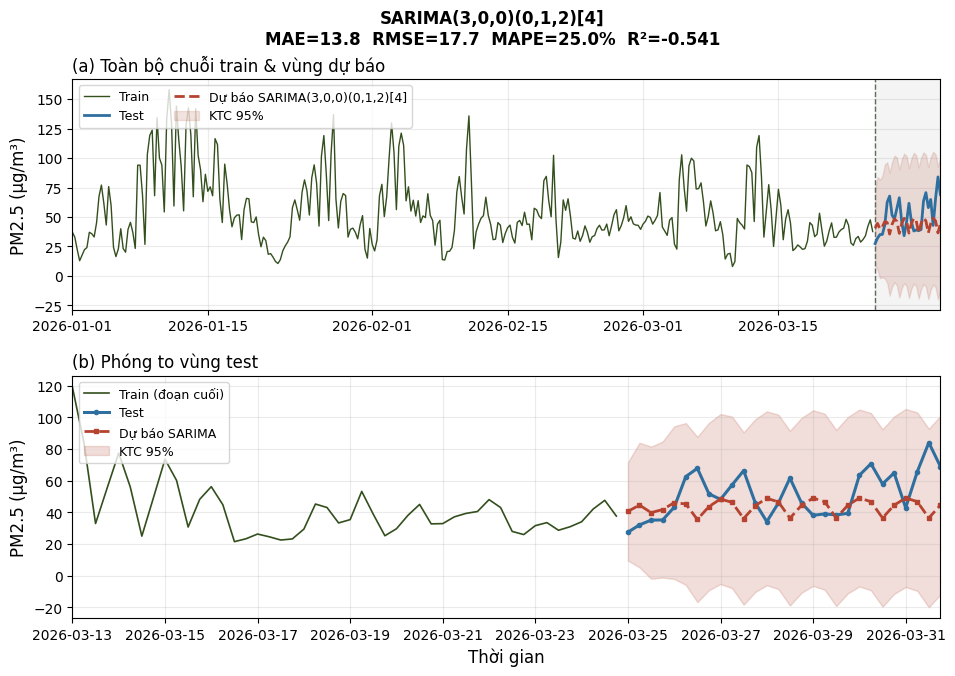

In [104]:
train_time  = train.index
test_time   = test.index
y_train     = train.to_numpy()
y_test      = test.to_numpy()
fc_arr      = np.asarray(sarima_forecast, dtype=float).ravel()
lower       = conf_int.iloc[:, 0].to_numpy()
upper       = conf_int.iloc[:, 1].to_numpy()

fig, (ax0, ax1) = plt.subplots(
    2, 1, figsize=(11.2, 7.0), sharey=False,
    gridspec_kw={"height_ratios": [1.0, 1.05], "hspace": 0.28}
)

ax0.plot(train_time, y_train, color=GREEN, linewidth=1.0, label="Train")
ax0.plot(test_time,  y_test,  color=BLUE,  linewidth=2.0, label="Test",     zorder=4)
ax0.plot(test_time,  fc_arr,  color=RED,   linewidth=2.0, linestyle="--",
         label=f"Dự báo {model_label}", zorder=5)
ax0.fill_between(test_time, lower, upper, color=RED, alpha=0.15,
                 label="KTC 95%", zorder=2)
ax0.axvspan(test_time[0], test_time[-1], color=GRAY, alpha=0.07)
ax0.axvline(test_time[0], color=GRAY, linestyle="--", linewidth=1.0)
ax0.set_ylabel("PM2.5 (µg/m³)")
ax0.set_title("(a) Toàn bộ chuỗi train & vùng dự báo", loc="left", fontsize=12)
ax0.legend(loc="upper left", frameon=True, fontsize=9, ncol=2)
ax0.grid(alpha=0.25)
ax0.set_xlim(train_time[0], test_time[-1])

z_lo = train_time[-48] if len(train_time) >= 48 else train_time[0]
mask = train_time >= z_lo
ax1.plot(train_time[mask], y_train[mask], color=GREEN, linewidth=1.2,
         label="Train (đoạn cuối)")
ax1.plot(test_time, y_test, color=BLUE,  linewidth=2.2,
         marker="o", markersize=3, label="Test")
ax1.plot(test_time, fc_arr, color=RED,   linewidth=2.0, linestyle="--",
         marker="s", markersize=3, label="Dự báo SARIMA")
ax1.fill_between(test_time, lower, upper, color=RED, alpha=0.18, label="KTC 95%")
ax1.set_xlabel("Thời gian")
ax1.set_ylabel("PM2.5 (µg/m³)")
ax1.set_title("(b) Phóng to vùng test", loc="left", fontsize=12)
ax1.legend(loc="upper left", frameon=True, fontsize=9)
ax1.grid(alpha=0.25)
ax1.set_xlim(z_lo, test_time[-1])

metrics_str = f"MAE={mae:.1f}  RMSE={rmse:.1f}  MAPE={mape:.1f}%  R²={r2:.3f}"
fig.suptitle(f"{model_label}\n{metrics_str}", fontsize=12, fontweight="bold")
fig.tight_layout(pad=1.0, rect=[0, 0.03, 1, 0.93])
plt.show()

## ARIMAX - 8 biến ngoại sinh

In [107]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==========================================
# 1. CHUẨN BỊ DỮ LIỆU NỘI SINH VÀ NGOẠI SINH
# ==========================================
TARGET_COL = 'PM25'
# Chọn lọc các biến ngoại sinh thực sự có tác động (tránh nhiễu)
# exog_cols = ['Wind Speed', 'Precipitation', 'SO2', 'NO2']
exog_cols = ['Temperature', 'Clouds', 'Wind Speed', 'Precipitation', 'Pressure', 'Relative Humidity', 'SO2', 'NO2']

# Đọc file CSV
train_env = pd.read_csv("/kaggle/input/datasets/binhdanghai/data-6h/PM25_2026_Q1_train_6h.csv")
test_env = pd.read_csv("/kaggle/input/datasets/binhdanghai/data-6h/PM25_2026_Q1_test_6h.csv")

# 1. Chuyển cột Local Time sang định dạng chuẩn Datetime
train_env['Local Time'] = pd.to_datetime(train_env['Local Time'])
test_env['Local Time'] = pd.to_datetime(test_env['Local Time'])

train_env.set_index('Local Time', inplace=True)
test_env.set_index('Local Time', inplace=True)

train_env = train_env.asfreq('6H')
test_env = test_env.asfreq('6H')

# Lấy dữ liệu ngoại sinh (Exogenous variables)
exog_train = train_env[exog_cols]
exog_test  = test_env[exog_cols]

# Lấy dữ liệu nội sinh (Endogenous variable) và chuyển sang LOG
endog_train_log = train_env[TARGET_COL]
endog_test_raw  = test_env[TARGET_COL] # Giữ nguyên gốc để lát so sánh lỗi

## ARIMA(5, 0, 8)

Đang huấn luyện ARIMA(5,0,8)...
Mô hình được chọn: ARIMA(5,0,8)
                               SARIMAX Results                                
Dep. Variable:                   PM25   No. Observations:                  332
Model:                 ARIMA(5, 0, 8)   Log Likelihood               -1346.443
Date:                Mon, 04 May 2026   AIC                           2720.887
Time:                        17:58:33   BIC                           2773.774
Sample:                    01-01-2026   HQIC                          2741.998
                         - 03-24-2026                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8044      0.074     10.806      0.000       0.659       0.950
ar.L2          0.0083      0.052      0.160      0.873      -0.094 

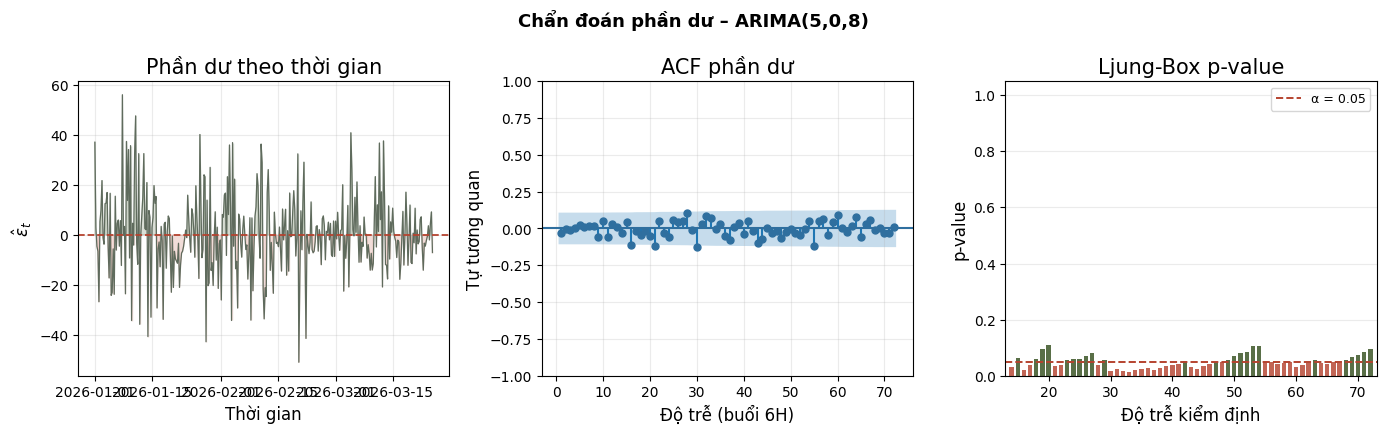


Metric        Giá trị
----------------------
MAE           14.0001
RMSE          17.6736
MAPE           24.69%
WAPE           27.34%
R²            -0.5300


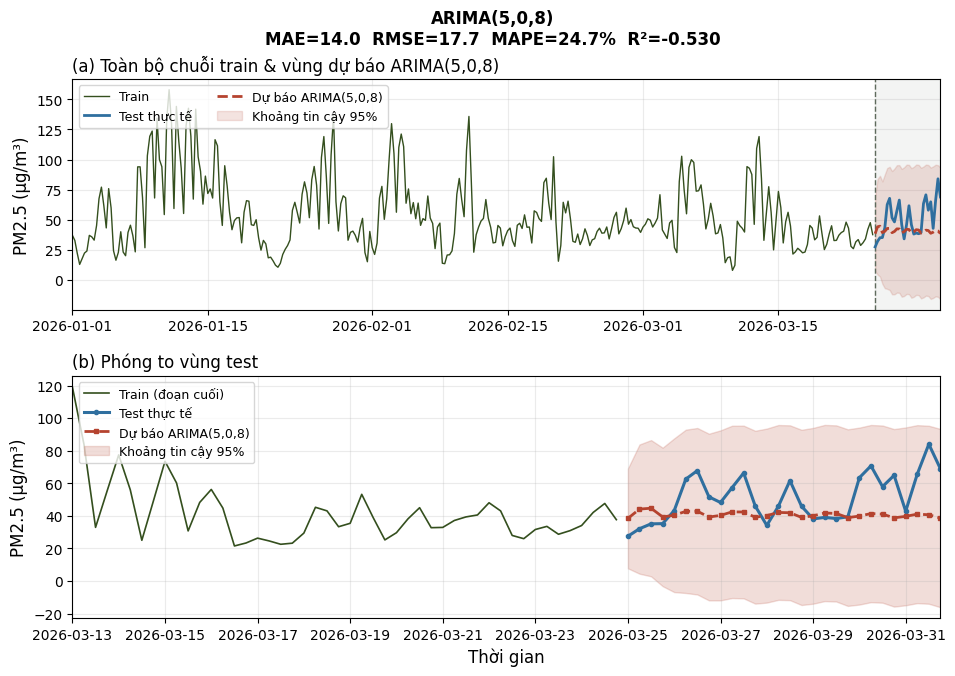

In [109]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf as sm_plot_acf
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ==============================================================================
# 1. KHỞI TẠO VÀ HUẤN LUYỆN MÔ HÌNH ARIMA(5, 0, 8)
# ==============================================================================
selected_order = (5, 0, 8)
p, d, q = selected_order
model_label = f"ARIMA({p},{d},{q})"

print(f"Đang huấn luyện {model_label}...")

# Lấy dữ liệu train an toàn (phòng trường hợp train đang là DataFrame)
y_train_safe = train['PM25'] if isinstance(train, pd.DataFrame) else train

final_model = ARIMA(
    y_train_safe,
    order=selected_order,
    trend="n",
    enforce_stationarity=False,
    enforce_invertibility=False
)
final_result = final_model.fit()

print(f"Mô hình được chọn: {model_label}")
print(final_result.summary())

# ==============================================================================
# 2. CHẨN ĐOÁN PHẦN DƯ (DIAGNOSTICS)
# ==============================================================================
residuals = final_result.resid.dropna()

# Bậc tự do hiệu chỉnh = p + q cho ARIMA (Không có P, Q của mùa vụ)
model_df = p + q 
max_lag  = 3 * 24  # 72 giờ

lb_lags = list(range(model_df + 1, max_lag + 1))
if not lb_lags:
    raise ValueError(f"model_df={model_df} >= max_lag={max_lag}, không còn lag hợp lệ.")

ljung_box_result = acorr_ljungbox(
    residuals, lags=lb_lags, model_df=model_df, return_df=True
)

print(f"\nMô hình: {model_label}")
print(f"model_df = p + q = {model_df}")
print(ljung_box_result.tail(10))

resid_values = residuals.to_numpy(dtype=float)
resid_time   = residuals.index
lags_full    = ljung_box_result.index.to_numpy()
pvals_full   = ljung_box_result["lb_pvalue"].to_numpy()

# Cấu hình màu sắc (Khởi tạo lại tránh lỗi chưa define)
GREEN, BLUE, RED, GRAY = "#344f1e", "#2f6f9f", "#b5432f", "#5f6b5d"

fig, axes = plt.subplots(1, 3, figsize=(14.0, 4.4))

# ── Chuỗi phần dư ────────────────────────────────────────────────────────
axes[0].plot(resid_time, resid_values, color=GRAY, linewidth=0.9)
axes[0].axhline(0, color=RED, linestyle="--", linewidth=1.3)
axes[0].fill_between(resid_time, 0, resid_values,
    where=(resid_values >= 0), color=GREEN, alpha=0.18)
axes[0].fill_between(resid_time, 0, resid_values,
    where=(resid_values <  0), color=RED,   alpha=0.18)
axes[0].set_title("Phần dư theo thời gian")
axes[0].set_xlabel("Thời gian")
axes[0].set_ylabel(r"$\hat{\varepsilon}_t$")
axes[0].grid(alpha=0.25)

# ── ACF phần dư ──────────────────────────────────────────────────────────
sm_plot_acf(residuals, ax=axes[1], lags=max_lag,
            zero=False, color=BLUE, alpha=0.05)
axes[1].set_title("ACF phần dư")
axes[1].set_xlabel("Độ trễ (buổi 6H)")
axes[1].set_ylabel("Tự tương quan")
axes[1].grid(alpha=0.25)

# ── Ljung-Box p-values ────────────────────────────────────────────────────
axes[2].bar(lags_full, pvals_full,
    color=[GREEN if p > 0.05 else RED for p in pvals_full],
    alpha=0.82, width=0.7)
axes[2].axhline(0.05, color=RED, linestyle="--", linewidth=1.4, label="α = 0.05")
axes[2].set_title("Ljung-Box p-value")
axes[2].set_xlabel("Độ trễ kiểm định")
axes[2].set_ylabel("p-value")
axes[2].set_xlim(model_df, max_lag + 1)
axes[2].set_ylim(0, 1.05)
axes[2].legend(frameon=True, fontsize=9)
axes[2].grid(axis="y", alpha=0.25)

fig.suptitle(f"Chẩn đoán phần dư – {model_label}", fontsize=13, fontweight="bold")
fig.tight_layout(pad=1.2)
plt.show()

# ==============================================================================
# 3. DỰ BÁO VÀ ĐÁNH GIÁ (METRICS)
# ==============================================================================
n_steps         = len(test)
forecast_result = final_result.get_forecast(steps=n_steps)
arima_forecast  = forecast_result.predicted_mean
conf_int        = forecast_result.conf_int()

# --- XỬ LÝ AN TOÀN TRÁNH LỖI STRING TO FLOAT ---
# Trích xuất mảng giá trị thực tế chuẩn số thực 1D
y_test_safe = np.asarray(test['PM25'] if isinstance(test, pd.DataFrame) else test, dtype=float).flatten()

# ── Metrics ──────────────────────────────────────────────────────────────
mae  = mean_absolute_error(y_test_safe, arima_forecast)
rmse = np.sqrt(mean_squared_error(y_test_safe, arima_forecast))
r2   = 1 - np.sum((y_test_safe - arima_forecast)**2) / np.sum((y_test_safe - y_test_safe.mean())**2)
wape = np.sum(np.abs(y_test_safe - arima_forecast)) / np.sum(np.abs(y_test_safe)) * 100

nonzero_mask = y_test_safe != 0
mape = np.mean(np.abs(
    (y_test_safe[nonzero_mask] - arima_forecast.values[nonzero_mask]) / y_test_safe[nonzero_mask]
)) * 100

print(f"\n{'Metric':<8} {'Giá trị':>12}")
print("-" * 22)
print(f"{'MAE':<8} {mae:>12.4f}")
print(f"{'RMSE':<8} {rmse:>12.4f}")
print(f"{'MAPE':<8} {mape:>11.2f}%")
print(f"{'WAPE':<8} {wape:>11.2f}%")
print(f"{'R²':<8} {r2:>12.4f}")

# ==============================================================================
# 4. TRỰC QUAN HÓA KẾT QUẢ DỰ BÁO
# ==============================================================================
# Trích xuất an toàn trục thời gian và tập train, ép về numpy array để dùng được [-1]
train_time = (pd.to_datetime(train['Local Time']) if isinstance(train, pd.DataFrame) and 'Local Time' in train.columns else train.index).to_numpy()
test_time  = (pd.to_datetime(test['Local Time']) if isinstance(test, pd.DataFrame) and 'Local Time' in test.columns else test.index).to_numpy()

y_train_safe = np.asarray(y_train_safe, dtype=float).flatten()
fc_arr       = np.asarray(arima_forecast, dtype=float).ravel()
lower        = conf_int.iloc[:, 0].to_numpy()
upper        = conf_int.iloc[:, 1].to_numpy()

fig, (ax0, ax1) = plt.subplots(
    2, 1, figsize=(11.2, 7.0), sharey=False,
    gridspec_kw={"height_ratios": [1.0, 1.05], "hspace": 0.28}
)

ax0.plot(train_time, y_train_safe, color=GREEN, linewidth=1.0, label="Train")
ax0.plot(test_time,  y_test_safe,  color=BLUE,  linewidth=2.0, label="Test thực tế", zorder=4)
ax0.plot(test_time,  fc_arr,       color=RED,   linewidth=2.0, linestyle="--",
         label=f"Dự báo {model_label}", zorder=5)
ax0.fill_between(test_time, lower, upper, color=RED, alpha=0.15,
                 label="Khoảng tin cậy 95%", zorder=2)
ax0.axvspan(test_time[0], test_time[-1], color=GRAY, alpha=0.07)
ax0.axvline(test_time[0], color=GRAY, linestyle="--", linewidth=1.0)
ax0.set_ylabel("PM2.5 (µg/m³)")
ax0.set_title(f"(a) Toàn bộ chuỗi train & vùng dự báo {model_label}", loc="left", fontsize=12)
ax0.legend(loc="upper left", frameon=True, fontsize=9, ncol=2)
ax0.grid(alpha=0.25)
ax0.set_xlim(train_time[0], test_time[-1])

# Phóng to 48 bước (12 ngày với dữ liệu 6H)
z_lo = train_time[-48] if len(train_time) >= 48 else train_time[0]
mask = train_time >= z_lo
ax1.plot(train_time[mask], y_train_safe[mask], color=GREEN, linewidth=1.2,
         label="Train (đoạn cuối)")
ax1.plot(test_time, y_test_safe, color=BLUE,  linewidth=2.2,
         marker="o", markersize=3, label="Test thực tế")
ax1.plot(test_time, fc_arr,      color=RED,   linewidth=2.0, linestyle="--",
         marker="s", markersize=3, label=f"Dự báo {model_label}")
ax1.fill_between(test_time, lower, upper, color=RED, alpha=0.18, label="Khoảng tin cậy 95%")
ax1.set_xlabel("Thời gian")
ax1.set_ylabel("PM2.5 (µg/m³)")
ax1.set_title("(b) Phóng to vùng test", loc="left", fontsize=12)
ax1.legend(loc="upper left", frameon=True, fontsize=9)
ax1.grid(alpha=0.25)
ax1.set_xlim(z_lo, test_time[-1])

metrics_str = f"MAE={mae:.1f}  RMSE={rmse:.1f}  MAPE={mape:.1f}%  R²={r2:.3f}"
fig.suptitle(f"{model_label}\n{metrics_str}", fontsize=12, fontweight="bold")
fig.tight_layout(pad=1.0, rect=[0, 0.03, 1, 0.93])
plt.show()

# Đọc DL

In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [111]:
train_valid = pd.read_csv('/kaggle/input/datasets/binhdanghai/data-6h/PM25_2026_Q1_train_6h.csv')
test = pd.read_csv('/kaggle/input/datasets/binhdanghai/data-6h/PM25_2026_Q1_test_6h.csv')


In [112]:
print("Train - Valid shape:", train_valid.shape)
print("Test shape:", test.shape)

Train - Valid shape: (332, 14)
Test shape: (28, 14)


In [113]:
print("======= DATA INFO =======")
print(train_valid.info())

======= DATA INFO =======
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 332 entries, 0 to 331
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Local Time         332 non-null    object 
 1   AQI                332 non-null    float64
 2   CO                 332 non-null    float64
 3   NO2                332 non-null    float64
 4   O3                 332 non-null    float64
 5   PM10               332 non-null    float64
 6   PM25               332 non-null    float64
 7   SO2                332 non-null    float64
 8   Clouds             332 non-null    float64
 9   Precipitation      332 non-null    float64
 10  Pressure           332 non-null    float64
 11  Relative Humidity  332 non-null    float64
 12  Temperature        332 non-null    float64
 13  Wind Speed         332 non-null    float64
dtypes: float64(13), object(1)
memory usage: 36.4+ KB
None


In [114]:
train_valid.head(5)

,Local Time,AQI,CO,NO2,O3,PM10,PM25,SO2,Clouds,Precipitation,Pressure,Relative Humidity,Temperature,Wind Speed
0,2026-01-01 00:00:00,120.166667,526.333333,29.450000,53.333333,38.033333,37.066667,29.216667,84.500000,0.066667,1011.383333,96.333333,18.866667,9.400000
1,2026-01-01 06:00:00,108.500000,671.833333,33.083333,61.333333,33.750000,32.866667,36.266667,98.333333,0.150000,1014.733333,91.666667,19.516667,8.250000
2,2026-01-01 12:00:00,97.833333,626.500000,23.683333,74.000000,22.633333,22.250000,29.716667,95.833333,0.300000,1014.516667,78.833333,21.633333,12.633333
3,2026-01-01 18:00:00,87.000000,832.833333,17.350000,60.666667,13.083333,12.916667,26.266667,100.000000,0.250000,1017.583333,82.166667,18.216667,17.116667
4,2026-01-02 00:00:00,75.333333,682.166667,16.833333,48.000000,17.933333,17.683333,29.433333,100.000000,0.116667,1018.983333,81.666667,16.216667,12.283333


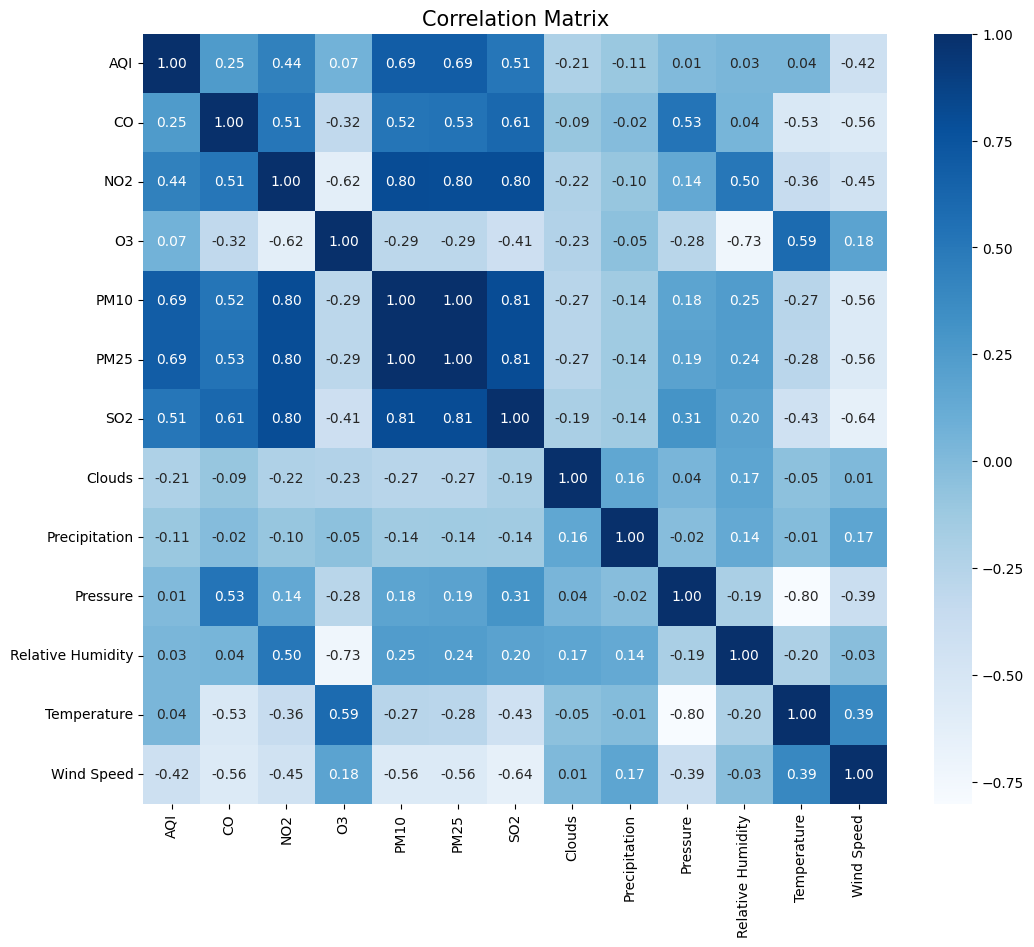

In [115]:
# Ma trận tương quan giữa các biến định lượng
numeric_columns = train_valid.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12, 10))
sns.heatmap(numeric_columns.corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()



# Feature Engineering
XGBoost cần thôi còn LSTM không cần

In [116]:
from statsmodels.tsa.seasonal import MSTL
from sklearn.preprocessing import StandardScaler

In [117]:
# Hàm trích xuất quy luật mùa vụ (chỉ dùng cho tập train)
def extract_seasonal_profiles(df):
    df_new = df.copy()
    
    df_new['Local Time'] = pd.to_datetime(df_new['Local Time'])
        
    # Phân rã MSTL
    mstl_model = MSTL(df_new['PM25'], periods=[4, 28])
    res = mstl_model.fit()

    df_new['seasonal_4'] = res.seasonal['seasonal_4']
    df_new['seasonal_28'] = res.seasonal['seasonal_28']
    
    # Tạo từ điển quy luật mùa vụ theo giờ và tuần
    df_new['hour'] = df_new['Local Time'].dt.hour
    df_new['day_of_week'] = df_new['Local Time'].dt.dayofweek
    df_new['weekday_hour'] = df_new['day_of_week'].astype(str) + "_" + df_new['hour'].astype(str)
    df_new['month_hour'] = df_new['Local Time'].dt.month.astype(str) + "_" + df_new['hour'].astype(str)
    df_new['month_weekday_hour'] = df_new['Local Time'].dt.month.astype(str) + "_" + df_new['day_of_week'].astype(str) + "_" + df_new['hour'].astype(str)
    
    profile_4 = df_new.groupby('month_hour')['seasonal_4'].mean().to_dict()
    profile_28 = df_new.groupby('month_weekday_hour')['seasonal_28'].mean().to_dict()    
    return profile_4, profile_28

Đầu vào Mùa vụ: Đổi tên profile_24, profile_168 thành profile_4 và profile_28 cho khớp với kết quả từ hàm phân rã MSTL hôm trước.

Giờ cao điểm (is_peak_hour): Dữ liệu 6H chỉ có các mốc 0h, 6h, 12h, 18h. Các mốc 7, 8 hay 17 không còn tồn tại nữa. Mình đã sửa lại thành [6, 18] (Đại diện cho cao điểm sáng đi làm và chiều tan tầm).

Trễ (Lags): 1 ngày lùi 4 bước (shift(4)), 7 ngày lùi 28 bước (shift(28)). Mình cũng đổi tên biến thành pm25_lag1d cho trực quan.

Trượt (Rolling): Cửa sổ 3h không còn tồn tại ở dữ liệu 6H. Mình thay thế bằng cửa sổ window=2 (tương đương 12 giờ). Cửa sổ 1 ngày là window=4, 1 tuần là window=28. (Vẫn giữ .shift(1) của bạn - một thói quen chống data leakage cực kỳ tốt!).

In [118]:
import pandas as pd

# Hàm trích chọn đặc trưng (dùng cho cả train và test)
def extract_features(df, profile_4, profile_28, use_env = True):
    df_new = df.copy()
    
    # Chuyển định dạng ngày tháng
    df_new['Local Time'] = pd.to_datetime(df_new['Local Time'])
    
    # Tạo các đặc trưng về thời gian 
    df_new['hour'] = df_new['Local Time'].dt.hour
    df_new['day_of_week'] = df_new['Local Time'].dt.dayofweek
    df_new['month'] = df_new['Local Time'].dt.month
    df_new['season'] = df_new['month'].apply(lambda x: (x%12 + 4)//3)  
    df_new['is_dry_season'] = df_new['month'].isin([11, 12, 1, 2, 3, 4]).astype(int)    
    df_new['is_weekend'] = df_new['day_of_week'].isin([5, 6]).astype(int)
    
    # Ở chu kỳ 6H (0, 6, 12, 18), cao điểm giao thông rơi vào 6h sáng và 18h tối
    df_new['is_peak_hour'] = df_new['hour'].isin([6, 18]).astype(int)
    
    df_new['month_hour'] = df_new['month'].astype(str) + "_" + df_new['hour'].astype(str)
    df_new['month_weekday_hour'] = df_new['month'].astype(str) + "_" + df_new['day_of_week'].astype(str) + "_" + df_new['hour'].astype(str)
    
    # Map các quy luật mùa vụ đã trích xuất từ tập train
    df_new['seasonal_4'] = df_new['month_hour'].map(profile_4)
    df_new['seasonal_28'] = df_new['month_weekday_hour'].map(profile_28)
    df_new.drop(columns=['month_hour', 'month_weekday_hour'], inplace=True) # Xóa 2 cột trung gian
        
    # Tạo các đặc trưng về lag (1 ngày = 4 buổi)
    df_new['pm25_lag1'] = df_new['PM25'].shift(1)     # Lùi 1 buổi (6 giờ)
    df_new['pm25_lag1d'] = df_new['PM25'].shift(4)    # Lùi 1 ngày (4 buổi)
    df_new['pm25_lag7d'] = df_new['PM25'].shift(28)   # Lùi 7 ngày (28 buổi)
    
    # Tạo các đặc trưng về rolling (thêm shift để tránh data leakage)
    df_new['pm25_rolling_12h'] = df_new['PM25'].rolling(window=2).mean().shift(1)  # Trung bình 12h (2 buổi)
    df_new['pm25_rolling_1d']  = df_new['PM25'].rolling(window=4).mean().shift(1)  # Trung bình 1 ngày (4 buổi)
    df_new['pm25_rolling_7d']  = df_new['PM25'].rolling(window=28).mean().shift(1) # Trung bình 7 ngày (28 buổi)
    df_new['pm25_rolling_1d_std'] = df_new['PM25'].rolling(window=4).std().shift(1) # Độ lệch chuẩn 1 ngày
    
    base_features = ['hour', 'day_of_week', 'month', 'season', 'is_dry_season', 'is_weekend', 'is_peak_hour',
                     'seasonal_4', 'seasonal_28',
                     'pm25_lag1', 'pm25_lag1d', 'pm25_lag7d',
                     'pm25_rolling_12h', 'pm25_rolling_1d', 'pm25_rolling_7d', 'pm25_rolling_1d_std']
    
    env_features = ['Temperature', 'Clouds', 'Wind Speed', 'Precipitation', 'Pressure', 'Relative Humidity']
    
    features = (env_features + base_features) if use_env else base_features
    return df_new, features

In [119]:
import pandas as pd

# Hàm chuẩn bị dữ liệu 
# Thêm 2 tham số valid_start và test_start để linh hoạt chia tập dữ liệu
def prepare_data(train_valid, test, valid_start='2026-03-01', test_start='2026-03-25', use_env=True):
    # Lọc tập train dựa trên mốc thời gian linh hoạt
    train = train_valid[train_valid['Local Time'] < valid_start].copy()
    
    # Trích xuất quy luật mùa vụ từ tập train (Đã đổi tên biến theo dữ liệu 6H)
    profile_4, profile_28 = extract_seasonal_profiles(train)
    
    # Gộp dữ liệu để tính Lag/Rolling không bị hụt ở đầu tập Valid/Test
    combined = pd.concat([train_valid, test], ignore_index=True)
    combined.sort_values('Local Time', inplace=True)    # Sắp xếp theo thời gian
    combined.reset_index(drop=True, inplace=True)       # Cập nhật lại index
    
    # Trích chọn đặc trưng cho cả 3 tập (Truyền đúng tên profile_4, profile_28)
    data_prepared, features = extract_features(combined, profile_4, profile_28, use_env)
    
    # Chia lại train, valid, test dựa trên mốc thời gian mới
    train = data_prepared[data_prepared['Local Time'] < valid_start].copy()
    valid = data_prepared[(data_prepared['Local Time'] >= valid_start) & (data_prepared['Local Time'] < test_start)].copy()
    test  = data_prepared[data_prepared['Local Time'] >= test_start].copy()
    
    # Xóa các hàng có giá trị NaN do việc tạo đặc trưng lag và rolling (Chỉ làm trên Train)
    train = train.dropna(subset=features + ['PM25']).reset_index(drop=True)
    
    # Tách features và target
    X_train = train[features].values
    y_train = train['PM25'].values
    
    X_valid = valid[features].values
    y_valid = valid['PM25'].values
    
    X_test = test[features].values
    y_test = test['PM25'].values
    
    print("Đã chuẩn bị xong dữ liệu :>")
    print("Train shape:", X_train.shape, y_train.shape)
    print("Valid shape:", X_valid.shape, y_valid.shape)
    print("Test shape:", X_test.shape, y_test.shape)

    return X_train, y_train, X_valid, y_valid, X_test, y_test, features

In [120]:
X_train_all_ft, y_train, X_valid_all_ft, y_valid, X_test_all_ft, y_test, features = prepare_data(train_valid, test, valid_start='2026-03-01', test_start='2026-03-25', use_env=True)

Đã chuẩn bị xong dữ liệu :>
Train shape: (208, 22) (208,)
Valid shape: (96, 22) (96,)
Test shape: (28, 22) (28,)


# Modeling

In [122]:
from sklearn.pipeline import Pipeline
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

In [123]:
def evaluate_model(y_true, y_pred, model_name="MÔ HÌNH", scaler=None, n_features=None, target_idx=None):

    # Ép về mảng 1 chiều tránh lỗi kích thước
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    
    # Map về giá trị gốc
    if scaler is not None and n_features is not None and target_idx is not None:
        # Tạo ma trận giả cho y_true
        dummy_true = np.zeros((len(y_true), n_features))
        dummy_true[:, target_idx] = y_true
        y_true_real = scaler.inverse_transform(dummy_true)[:, target_idx]
            
        # Tạo ma trận giả cho y_pred
        dummy_pred = np.zeros((len(y_pred), n_features))
        dummy_pred[:, target_idx] = y_pred
        y_pred_real = scaler.inverse_transform(dummy_pred)[:, target_idx]
        
    else:
        y_true_real = y_true
        y_pred_real = y_pred
        
    mae = mean_absolute_error(y_true_real, y_pred_real)
    mse = mean_squared_error(y_true_real, y_pred_real)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true_real, y_pred_real)
    
    # In kết quả
    print(f"\n========== KẾT QUẢ: {model_name.upper()} ==========")
    print(f"MAE:  {mae:.4f}")
    print(f"MSE:  {mse:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"R2:   {r2:.4f}")
    print("=========================================")
    
    return y_true_real, y_pred_real

## XGBoost

In [124]:
def xgboost_pipeline(X_train, y_train, X_valid, y_valid): 
    
    # Định nghĩa các bước trong pipeline
    pipeline = Pipeline([
        ('model', XGBRegressor(
            n_estimators=100, 
            learning_rate=0.1, 
            max_depth=6, 
            random_state=42, 
            early_stopping_rounds=10))
    ])
    
    # Huấn luyện mô hình
    pipeline.fit(X_train, y_train, 
                 model__eval_set=[(X_valid, y_valid)],     # early stopping dựa trên cả tập validation
                 model__verbose=100)                  # In kết quả sau mỗi 100 vòng
    
    print("Hoàn tất huấn luyện mô hình XGBoost")
    
    return pipeline

In [125]:
model_xgboost = xgboost_pipeline(X_train_all_ft, y_train, X_valid_all_ft, y_valid)

y_pred_valid_xgb = model_xgboost.predict(X_valid_all_ft)

y_valid_pred, y_pred_xgb = evaluate_model(
    y_true=y_valid, 
    y_pred=y_pred_valid_xgb, 
    model_name="XGBoost"
)

[0]	validation_0-rmse:24.43689
[41]	validation_0-rmse:16.53187
Hoàn tất huấn luyện mô hình XGBoost

========== KẾT QUẢ: XGBOOST ==========
MAE:  12.6641
MSE:  271.1878
RMSE: 16.4678
R2:   0.4824


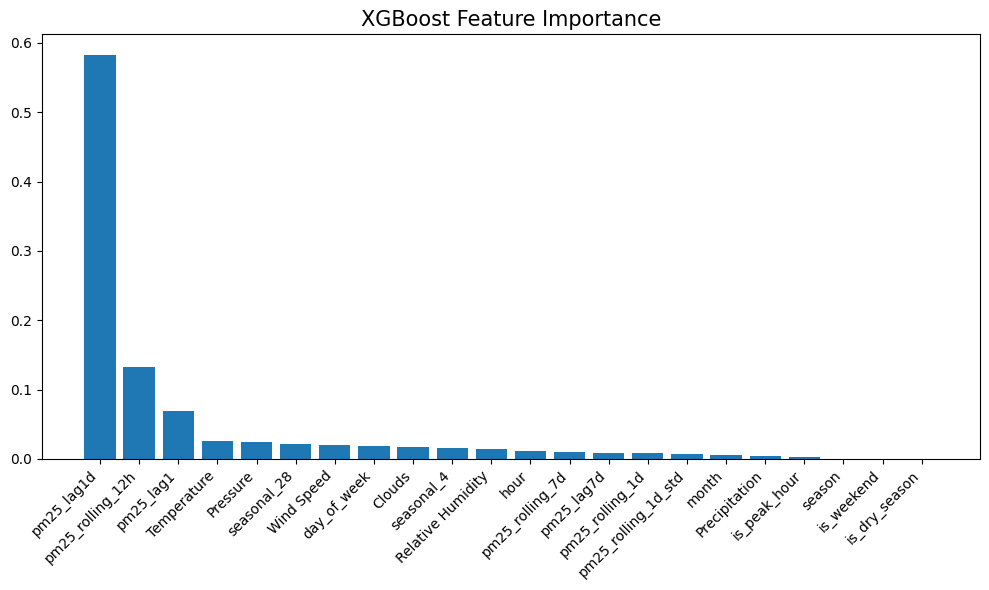

In [126]:
feat_imp = model_xgboost.named_steps['model'].feature_importances_
sorted_idx = np.argsort(feat_imp)[::-1]
plt.figure(figsize=(10, 6))
plt.bar(range(len(features)), feat_imp[sorted_idx])
plt.xticks(range(len(features)), [features[i] for i in sorted_idx], rotation=45, ha='right')
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

pm25_lag1 được sử dụng nhiều và giúp mô hình giảm nhiều sai số nhất (nhưng không biết có quan hệ phi tuyến hay tuyến tính với biến dự đoán hay không)

## LSTM

In [127]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
import time

In [128]:
# Set seed thư viện tf
tf.random.set_seed(42)

# Hàm tạo các chuỗi dữ liệu cho LSTM
def create_sequences(data, target_index, steps):
    X, y = [], []
    for i in range(len(data) - steps):
        X.append(data[i: i + steps, :])     # Dữ liệu đầu vào (cửa sổ trượt)
        y.append(data[i + steps, target_index])    # Giá trị PM25 tại t+1
        
    return np.array(X), np.array(y)

# Hàm chuyển dữ liệu về dạng 3D cho LSTM
# Thêm valid_start, test_start và đổi mặc định time_steps=4 (1 ngày dữ liệu 6H)
def prepare_data_lstm(train_valid, test, valid_start='2026-03-01', test_start='2026-03-25', time_steps=4, use_env=True):
    
    env_features = ['Temperature', 'Clouds', 'Wind Speed', 'Precipitation', 'Pressure', 'Relative Humidity', 'SO2', 'NO2']
    base_features = ['PM25']
    features = (env_features + base_features) if use_env else base_features
    
    # Chia tập dữ liệu dựa trên mốc thời gian động
    train = train_valid[train_valid['Local Time'] < valid_start].copy()
    valid = train_valid[(train_valid['Local Time'] >= valid_start) & (train_valid['Local Time'] < test_start)].copy()

    # Trích xuất numpy array
    train_data = train[features].values
    valid_data = valid[features].values
    test_data = test[features].values
    
    # Chuẩn hóa dữ liệu (Fit scaler chỉ trên tập Train để tránh Data Leakage)
    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train_data)
    valid_scaled = scaler.transform(valid_data)
    test_scaled = scaler.transform(test_data)
    
    # Vị trí cột PM25
    pm25_index = features.index('PM25')
    
    # --- XỬ LÝ CHỐNG MẤT DỮ LIỆU Ở ĐẦU TẬP VALID VÀ TEST ---
    # Mượn time_steps dòng cuối của tập trước nối vào đầu tập sau
    valid_scaled_extended = np.vstack((train_scaled[-time_steps:], valid_scaled))
    test_scaled_extended = np.vstack((valid_scaled[-time_steps:], test_scaled))
    
    # Tạo các chuỗi dữ liệu cho LSTM
    X_train, y_train = create_sequences(train_scaled, pm25_index, time_steps)
    X_valid, y_valid = create_sequences(valid_scaled_extended, pm25_index, time_steps)
    X_test, y_test = create_sequences(test_scaled_extended, pm25_index, time_steps)
    
    print("Đã chuẩn bị xong dữ liệu 3D cho LSTM :>")
    print("Train shape:", X_train.shape, y_train.shape)
    print("Valid shape:", X_valid.shape, y_valid.shape)
    print("Test shape:", X_test.shape, y_test.shape)
    
    return X_train, y_train, X_valid, y_valid, X_test, y_test, scaler, features

In [129]:
# Hàm huấn luyện LSTM
# --> ĐIỂM SỬA 1: Hạ batch_size xuống 16 do dữ liệu 6H ít dòng hơn rất nhiều
def lstm_model(X_train, y_train, X_valid, y_valid, batch_size=16, epochs=100):
    start_time = time.time()
    
    n_time_steps = X_train.shape[1]
    n_features = X_train.shape[2]
    
    model = Sequential([
        Input(shape=(n_time_steps, n_features)),
        
        # Lớp 1: Quét qua chuỗi dữ liệu quá khứ để học quy luật ngắn hạn
        LSTM(64, return_sequences=True, 
             kernel_regularizer=tf.keras.regularizers.l2(1e-4)),     # Thêm L2 chống overfitting
        Dropout(0.4),     # Tránh overfitting
        
        # Lớp 2: Nén các đặc trưng cốt lõi 
        LSTM(32, return_sequences=False, 
             kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        Dropout(0.4),
        
        # Đầu ra dự báo 
        Dense(16, activation='relu'),
        Dense(1)  # Dự đoán PM2.5
    ])
    
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    
    # Dừng sớm nếu loss không giảm sau 10 vòng
    early_stopping = EarlyStopping(
        monitor='val_loss', 
        patience=10, 
        restore_best_weights=True
    )
    
    # ReduceLROnPlateau: giảm Learning Rate khi val_loss chững lại
    reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,            # Giảm LR đi một nửa
        patience=5,            # Đợi 5 epoch không cải thiện thì giảm
        min_lr=1e-6,
        verbose=1
    )
    
    # Huấn luyện mô hình
    history = model.fit(X_train, y_train, 
                        validation_data=(X_valid, y_valid), 
                        epochs=epochs, 
                        batch_size=batch_size, 
                        callbacks=[early_stopping, reduce_lr],
                        verbose=1)     
    
    print(f"Hoàn tất huấn luyện mô hình LSTM: {time.time() - start_time:.2f} giây")
    return model, history

In [130]:
# Cách gọi hàm (bạn tự điều chỉnh mốc thời gian và time_steps cho phù hợp)
X_train_seq, y_train_seq, X_valid_seq, y_valid_seq, X_test_seq, y_test_seq, scaler, features_lstm = prepare_data_lstm(
    train_valid=train_valid, 
    test=test, 
    valid_start='2026-03-01', 
    test_start='2026-03-15', 
    time_steps=8,  # Lùi về quá khứ 8 buổi (2 ngày)
    use_env=True
)

print("X train shape:", X_train_seq.shape)

Đã chuẩn bị xong dữ liệu 3D cho LSTM :>
Train shape: (228, 8, 9) (228,)
Valid shape: (56, 8, 9) (56,)
Test shape: (28, 8, 9) (28,)
X train shape: (228, 8, 9)


In [131]:
model_lstm, history = lstm_model(X_train_seq, y_train_seq, X_valid_seq, y_valid_seq)

Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - loss: 0.9639 - mae: 0.7735 - val_loss: 0.5239 - val_mae: 0.5602 - learning_rate: 0.0010
Epoch 2/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.6471 - mae: 0.6158 - val_loss: 0.5511 - val_mae: 0.5658 - learning_rate: 0.0010
Epoch 3/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.5142 - mae: 0.5643 - val_loss: 0.5656 - val_mae: 0.5685 - learning_rate: 0.0010
Epoch 4/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.5589 - mae: 0.5532 - val_loss: 0.5391 - val_mae: 0.5563 - learning_rate: 0.0010
Epoch 5/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.5498 - mae: 0.5748 - val_loss: 0.5334 - val_mae: 0.5542 - learning_rate: 0.0010
Epoch 6/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.5034 - mae: 0.5508
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.5020 - mae: 0.5488 - val_loss: 0.5307 - val_mae: 0.5483 - learning_rate: 0.0010
Epoc

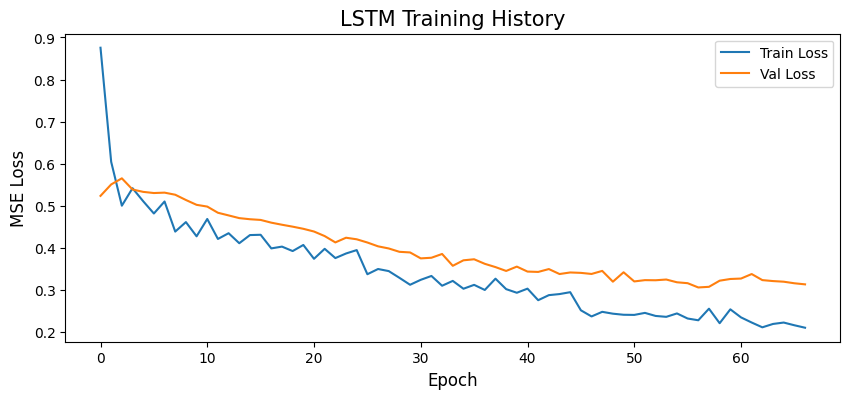

In [132]:
# Training curve
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('LSTM Training History')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

Dùng ReduceLR nên đã giảm được tình trạng overfitting ban đầu :< 

In [133]:
# Đánh giá mô hình lstm
y_valid_pred_scaled_lstm = model_lstm.predict(X_valid_seq)

y_valid, y_pred_lstm = evaluate_model(
    y_true=y_valid_seq, 
    y_pred=y_valid_pred_scaled_lstm, 
    model_name="LSTM",
    scaler=scaler,  
    n_features=X_train_seq.shape[2],
    target_idx=features_lstm.index('PM25')
)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 283ms/step

========== KẾT QUẢ: LSTM ==========
MAE:  13.1143
MSE:  281.6636
RMSE: 16.7828
R2:   0.5795


# Thực nghiệm

In [134]:
results = {}  # Lưu kết quả để so sánh cuối

# XGBoost
for use_env in [True, False]:
    label = "XGBoost_env" if use_env else "XGBoost_no_env"
    
    # Tính thời gian từ bước tạo features
    t_start = time.time()
    X_train, y_train, X_valid, y_valid, X_test, y_test, features = prepare_data(train_valid, test, use_env=use_env)
    model = xgboost_pipeline(X_train, y_train, X_valid, y_valid)
    t_elapsed = time.time() - t_start
    
    # Đánh giá
    y_pred = model.predict(X_valid)
    _, y_pred_real = evaluate_model(y_valid, y_pred, model_name=label)
    print(f"Tổng thời gian ({label}): {t_elapsed:.2f} giây")
    
    results[label] = {
        'model': model,
        'time': t_elapsed,
        'y_valid': y_valid,
        'y_pred': y_pred_real
    }

# LSTM 
for use_env in [True, False]:
    label = "LSTM_env" if use_env else "LSTM_no_env"
    
    t_start = time.time()
    X_tr, y_tr, X_vl, y_vl, X_te, y_te, scaler, features_lstm = prepare_data_lstm(train_valid, test, use_env=use_env)
    model_lstm, history = lstm_model(X_tr, y_tr, X_vl, y_vl)
    t_elapsed = time.time() - t_start
    
    # Đánh giá
    y_pred = model_lstm.predict(X_vl)
    y_true_real, y_pred_real = evaluate_model(y_vl, y_pred, model_name=label,
                                    scaler=scaler,
                                    n_features=len(features_lstm),
                                    target_idx=features_lstm.index('PM25'))
    print(f"Tổng thời gian ({label}): {t_elapsed:.2f} giây")
    
    
    results[label] = {
        'model': model_lstm,
        'scaler': scaler,
        'time': t_elapsed,
        'history': history,
        'y_valid': y_true_real,
        'y_pred': y_pred_real
    }

Đã chuẩn bị xong dữ liệu :>
Train shape: (208, 22) (208,)
Valid shape: (96, 22) (96,)
Test shape: (28, 22) (28,)
[0]	validation_0-rmse:24.43689
[41]	validation_0-rmse:16.53187
Hoàn tất huấn luyện mô hình XGBoost

========== KẾT QUẢ: XGBOOST_ENV ==========
MAE:  12.6641
MSE:  271.1878
RMSE: 16.4678
R2:   0.4824
Tổng thời gian (XGBoost_env): 0.14 giây
Đã chuẩn bị xong dữ liệu :>
Train shape: (208, 16) (208,)
Valid shape: (96, 16) (96,)
Test shape: (28, 16) (28,)
[0]	validation_0-rmse:24.17005
[17]	validation_0-rmse:21.09156
Hoàn tất huấn luyện mô hình XGBoost

========== KẾT QUẢ: XGBOOST_NO_ENV ==========
MAE:  17.3314
MSE:  415.6336
RMSE: 20.3871
R2:   0.2067
Tổng thời gian (XGBoost_no_env): 0.09 giây
Đã chuẩn bị xong dữ liệu 3D cho LSTM :>
Train shape: (232, 4, 9) (232,)
Valid shape: (96, 4, 9) (96,)
Test shape: (28, 4, 9) (28,)
Epoch 1/100
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - loss: 0.9770 - mae: 0.7259 - val_loss: 0.4419 - val_mae: 0.5216 - learning_rate: 0.0010
Epoch 2/100
15/15

In [135]:
xgb_core = model.steps[-1][1] if hasattr(model, 'steps') else model
    
if hasattr(xgb_core, 'best_iteration'):
    best_n_trees = xgb_core.best_iteration + 1
    print(f"[{label}] Số cây (best_n_estimators) tối ưu: {best_n_trees}")
else:
    print(f"[{label}] Không tìm thấy best_iteration")

[LSTM_no_env] Số cây (best_n_estimators) tối ưu: 8


In [136]:
# Bảng tổng kết
print("\n" + "="*60)
print("TỔNG KẾT CÁC THỰC NGHIỆM")
print("="*60)
print(f"{'Mô hình':<25} {'MAE':>8} {'RMSE':>8} {'R2':>8} {'Time(s)':>10}")
print("-"*60)
for label, res in results.items():
    mae  = mean_absolute_error(res['y_valid'], res['y_pred'])
    rmse = np.sqrt(mean_squared_error(res['y_valid'], res['y_pred']))
    r2   = r2_score(res['y_valid'], res['y_pred'])
    print(f"{label:<25} {mae:>8.4f} {rmse:>8.4f} {r2:>8.4f} {res['time']:>10.2f}")
print("="*60)


TỔNG KẾT CÁC THỰC NGHIỆM
Mô hình                        MAE     RMSE       R2    Time(s)
------------------------------------------------------------
XGBoost_env                12.6641  16.4678   0.4824       0.14
XGBoost_no_env             17.3314  20.3871   0.2067       0.09
LSTM_env                   10.0293  12.9762   0.6786      11.47
LSTM_no_env                10.5105  14.3688   0.6059      20.26


## Test

In [137]:
from tensorflow.keras.optimizers import Adam

In [138]:
# Gộp train - valid
def xgboost_pipeline_final(X_train, y_train, best_n_estimators=74):

    print(f"Đang huấn luyện XGBoost với {best_n_estimators} cây cố định...")
    
    # Khởi tạo mô hình 
    model = XGBRegressor(
        n_estimators=best_n_estimators,
        learning_rate=0.05, 
        max_depth=6,
        random_state=42,
        n_jobs=-1
    )
    
    # Chỉ fit trên tập Train (lúc này là tập gộp Train + Valid)
    model.fit(X_train, y_train)
    
    return model


# Không có early stopping, LR cố định
def lstm_model_final(X_train, y_train, best_epochs=20):
    print(f"Đang huấn luyện LSTM với {best_epochs} epochs cố định...")
    
    n_time_steps = X_train.shape[1]
    n_features = X_train.shape[2]
    
    model = Sequential([
        Input(shape=(n_time_steps, n_features)),
        
        # Lớp 1: Quét qua chuỗi dữ liệu quá khứ để học quy luật ngắn hạn
        LSTM(64, return_sequences=True, 
             kernel_regularizer=tf.keras.regularizers.l2(1e-4)),     # thêm L2 chống overfitting
        Dropout(0.4),     # Tránh overfitting
        
        # Lớp 2: Nén các đặc trưng cốt lõi 
        LSTM(32, return_sequences=False, 
             kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
        Dropout(0.4),
        
        # Đầu ra dự báo 
        Dense(16, activation='relu'),
        Dense(1)  # Dự đoán PM2.5
    ])
    
    # Sử dụng Learning Rate cố định đã tối ưu
    optimizer = Adam(learning_rate=2.5e-4) 
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])

    # Fit mô hình không có Valid
    history = model.fit(
        X_train, y_train,
        epochs=best_epochs,  
        batch_size=16,       # <-- SỬA: Hạ xuống 16 để model học mượt hơn với lượng dữ liệu gộp 6H
        verbose=1            
    )
    
    return model, history

In [139]:
results_test = {}

# XGBOOST TRÊN TẬP TRAIN_FINAL 
for use_env in [True, False]:
    label = "XGBoost_env_Final" if use_env else "XGBoost_no_env_Final"
    
    t_start = time.time()
    
    
    # Lấy dữ liệu (Chỉ lấy X_tr_final, y_tr_final và X_te, y_te)
    X_tr_final, y_tr_final, _, _, X_te, y_te, features = prepare_data(train_valid, test, use_env=use_env)
    
    # Huấn luyện trên tập gộp. 
    model_xgb = xgboost_pipeline_final(X_tr_final, y_tr_final, best_n_estimators=74)
    t_elapsed = time.time() - t_start
    
    # Đánh giá trên tập Test
    y_pred = model_xgb.predict(X_te)
    _, y_pred_real = evaluate_model(y_te, y_pred, model_name=label)
    
    print(f"Tổng thời gian ({label}): {t_elapsed:.2f} giây\n")
    
    results_test[label] = {
        'model': model_xgb,
        'time': t_elapsed,
        'y_test': y_te,
        'y_pred': y_pred_real
    }

# LSTM TRÊN TẬP TRAIN_FINAL 
for use_env in [True, False]:
    label = "LSTM_env_Final" if use_env else "LSTM_no_env_Final"
    
    t_start = time.time()
    
    # Lấy dữ liệu
    X_tr_final, y_tr_final, _, _, X_te, y_te, scaler, features_lstm = prepare_data_lstm(train_valid, test, use_env=use_env)
    
    # Huấn luyện trên tập gộp. 
    model_lstm, history = lstm_model_final(X_tr_final, y_tr_final, best_epochs=20) 
    t_elapsed = time.time() - t_start
    
    # Đánh giá trên tập Test
    y_pred = model_lstm.predict(X_te)
    y_true_real, y_pred_real = evaluate_model(y_te, y_pred, model_name=label,
                                    scaler=scaler,
                                    n_features=len(features_lstm),
                                    target_idx=features_lstm.index('PM25'))
    
    print(f"Tổng thời gian ({label}): {t_elapsed:.2f} giây\n")
    
    results_test[label] = {
        'model': model_lstm,
        'scaler': scaler,
        'time': t_elapsed,
        'history': history,
        'y_test': y_true_real,
        'y_pred': y_pred_real
    }

Đã chuẩn bị xong dữ liệu :>
Train shape: (208, 22) (208,)
Valid shape: (96, 22) (96,)
Test shape: (28, 22) (28,)
Đang huấn luyện XGBoost với 74 cây cố định...

========== KẾT QUẢ: XGBOOST_ENV_FINAL ==========
MAE:  10.9125
MSE:  170.5588
RMSE: 13.0598
R2:   0.1646
Tổng thời gian (XGBoost_env_Final): 0.18 giây

Đã chuẩn bị xong dữ liệu :>
Train shape: (208, 16) (208,)
Valid shape: (96, 16) (96,)
Test shape: (28, 16) (28,)
Đang huấn luyện XGBoost với 74 cây cố định...

========== KẾT QUẢ: XGBOOST_NO_ENV_FINAL ==========
MAE:  11.0467
MSE:  164.5126
RMSE: 12.8262
R2:   0.1942
Tổng thời gian (XGBoost_no_env_Final): 0.14 giây

Đã chuẩn bị xong dữ liệu 3D cho LSTM :>
Train shape: (232, 4, 9) (232,)
Valid shape: (96, 4, 9) (96,)
Test shape: (28, 4, 9) (28,)
Đang huấn luyện LSTM với 20 epochs cố định...
Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 1.0217 - mae: 0.7659
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9201 - mae: 0.7339
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━

In [140]:
# Bảng tổng kết
print("\n" + "="*60)
print("TỔNG KẾT CÁC THỰC NGHIỆM")
print("="*60)
print(f"{'Mô hình':<25} {'MAE':>8} {'RMSE':>8} {'R2':>8} {'Time(s)':>10}")
print("-"*60)
for label, res in results_test.items():
    mae  = mean_absolute_error(res['y_test'], res['y_pred'])
    rmse = np.sqrt(mean_squared_error(res['y_test'], res['y_pred']))
    r2   = r2_score(res['y_test'], res['y_pred'])
    print(f"{label:<25} {mae:>8.4f} {rmse:>8.4f} {r2:>8.4f} {res['time']:>10.2f}")
print("="*60)


TỔNG KẾT CÁC THỰC NGHIỆM
Mô hình                        MAE     RMSE       R2    Time(s)
------------------------------------------------------------
XGBoost_env_Final          10.9125  13.0598   0.1646       0.18
XGBoost_no_env_Final       11.0467  12.8262   0.1942       0.14
LSTM_env_Final             15.5729  20.4925  -1.0569       6.02
LSTM_no_env_Final          11.4070  14.0616   0.0315       5.99


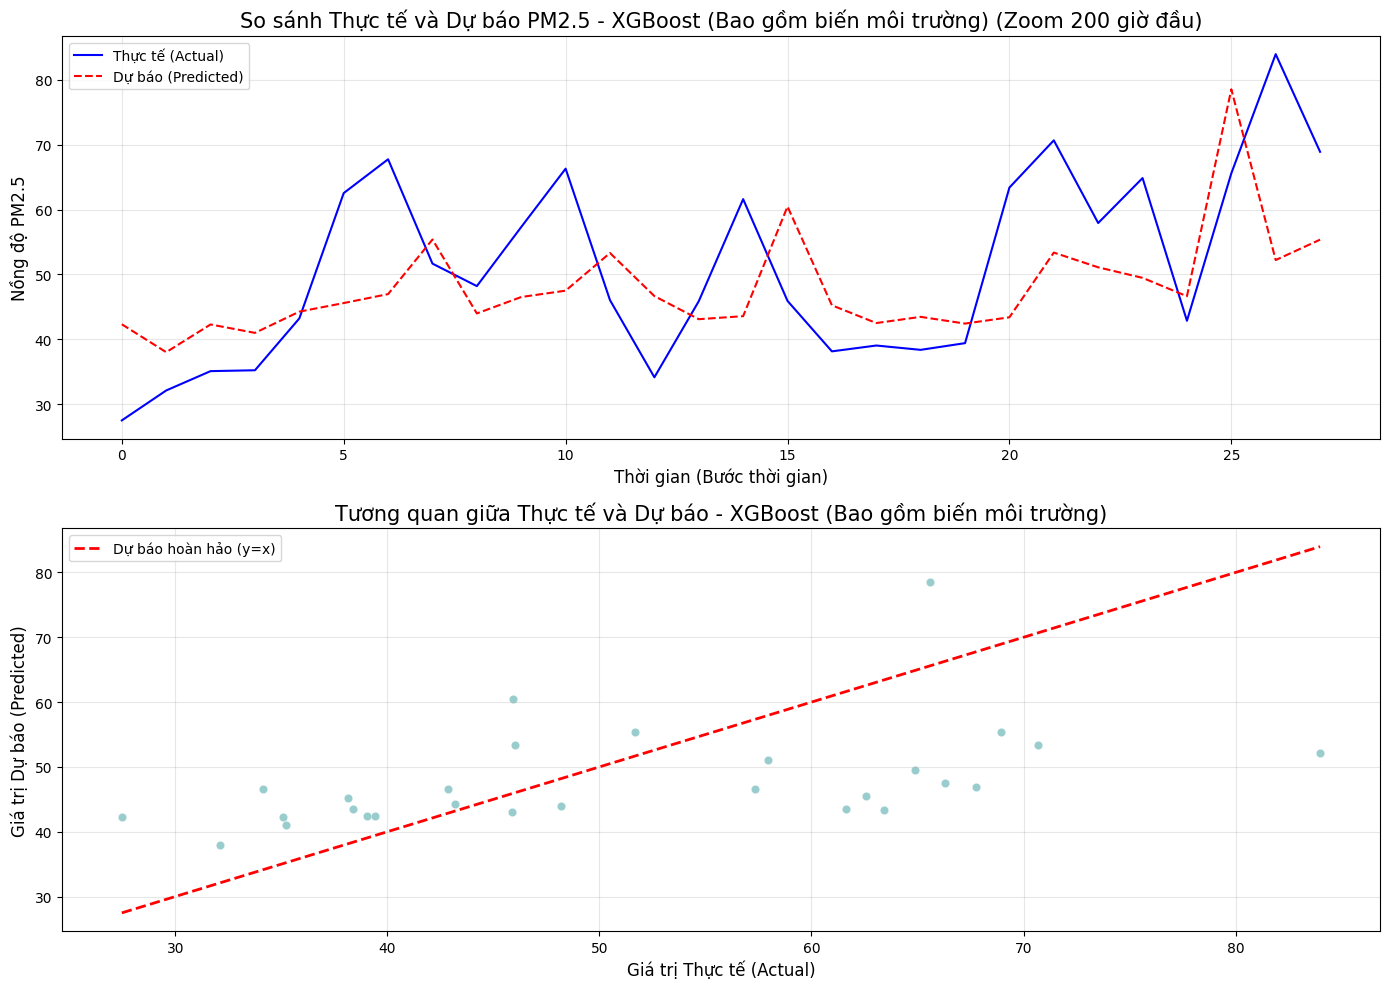

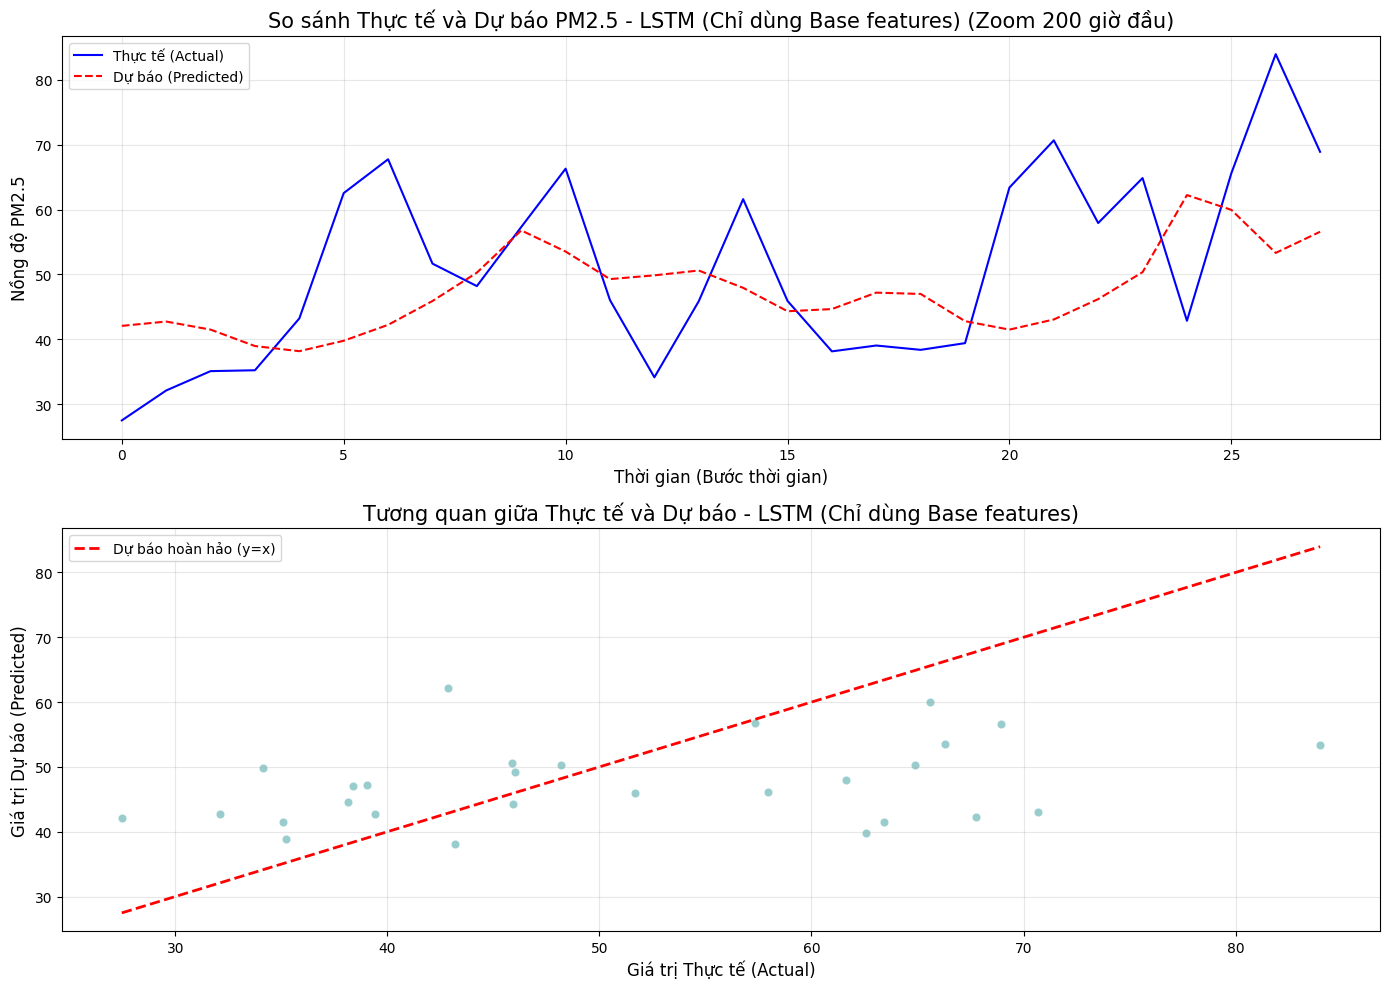

In [141]:
import numpy as np

def plot_actual_vs_predicted(y_true, y_pred, model_name="Mô hình", num_points=200):
    """
    Hàm vẽ đồ thị so sánh giá trị thực tế và dự báo PM2.5.
    y_true: mảng giá trị thực tế.
    y_pred: mảng giá trị dự báo.
    num_points: số lượng điểm dữ liệu cắt ra để vẽ biểu đồ đường (giúp dễ quan sát hơn).
    """
    # Đảm bảo dữ liệu ở dạng mảng 1 chiều
    y_true = np.array(y_true).flatten()
    y_pred = np.array(y_pred).flatten()
    
    plt.figure(figsize=(14, 10))

    # --- 1. Biểu đồ đường (Line Plot) theo thời gian ---
    plt.subplot(2, 1, 1)
    # Lấy num_points điểm đầu tiên (hoặc có thể đổi thành khoảng thời gian bạn muốn)
    plt.plot(y_true[:num_points], label='Thực tế (Actual)', color='blue', linewidth=1.5)
    plt.plot(y_pred[:num_points], label='Dự báo (Predicted)', color='red', linestyle='--', linewidth=1.5)
    
    plt.title(f'So sánh Thực tế và Dự báo PM2.5 - {model_name} (Zoom {num_points} giờ đầu)')
    plt.xlabel('Thời gian (Bước thời gian)')
    plt.ylabel('Nồng độ PM2.5')
    plt.legend()
    plt.grid(True, alpha=0.3)

    # --- 2. Biểu đồ phân tán (Scatter Plot) tương quan ---
    plt.subplot(2, 1, 2)
    sns.scatterplot(x=y_true, y=y_pred, alpha=0.4, color='teal')
    
    # Vẽ đường chéo y = x (hoàn hảo)
    min_val = min(np.min(y_true), np.min(y_pred))
    max_val = max(np.max(y_true), np.max(y_pred))
    plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Dự báo hoàn hảo (y=x)')

    plt.title(f'Tương quan giữa Thực tế và Dự báo - {model_name}')
    plt.xlabel('Giá trị Thực tế (Actual)')
    plt.ylabel('Giá trị Dự báo (Predicted)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# ==========================================
# CÁCH GỌI HÀM VỚI DỮ LIỆU CỦA BẠN
# ==========================================
# Dựa vào dictionary `results_test` bạn đã lưu ở bước đánh giá trước đó:

# Vẽ cho mô hình XGBoost (có biến môi trường)
y_test_xgb = results_test['XGBoost_env_Final']['y_test']
y_pred_xgb = results_test['XGBoost_env_Final']['y_pred']
plot_actual_vs_predicted(y_test_xgb, y_pred_xgb, model_name="XGBoost (Bao gồm biến môi trường)", num_points=200)

#Vẽ cho mô hình LSTM (không có biến môi trường)
y_test_lstm = results_test['LSTM_no_env_Final']['y_test']
y_pred_lstm = results_test['LSTM_no_env_Final']['y_pred']
plot_actual_vs_predicted(y_test_lstm, y_pred_lstm, model_name="LSTM (Chỉ dùng Base features)", num_points=200)

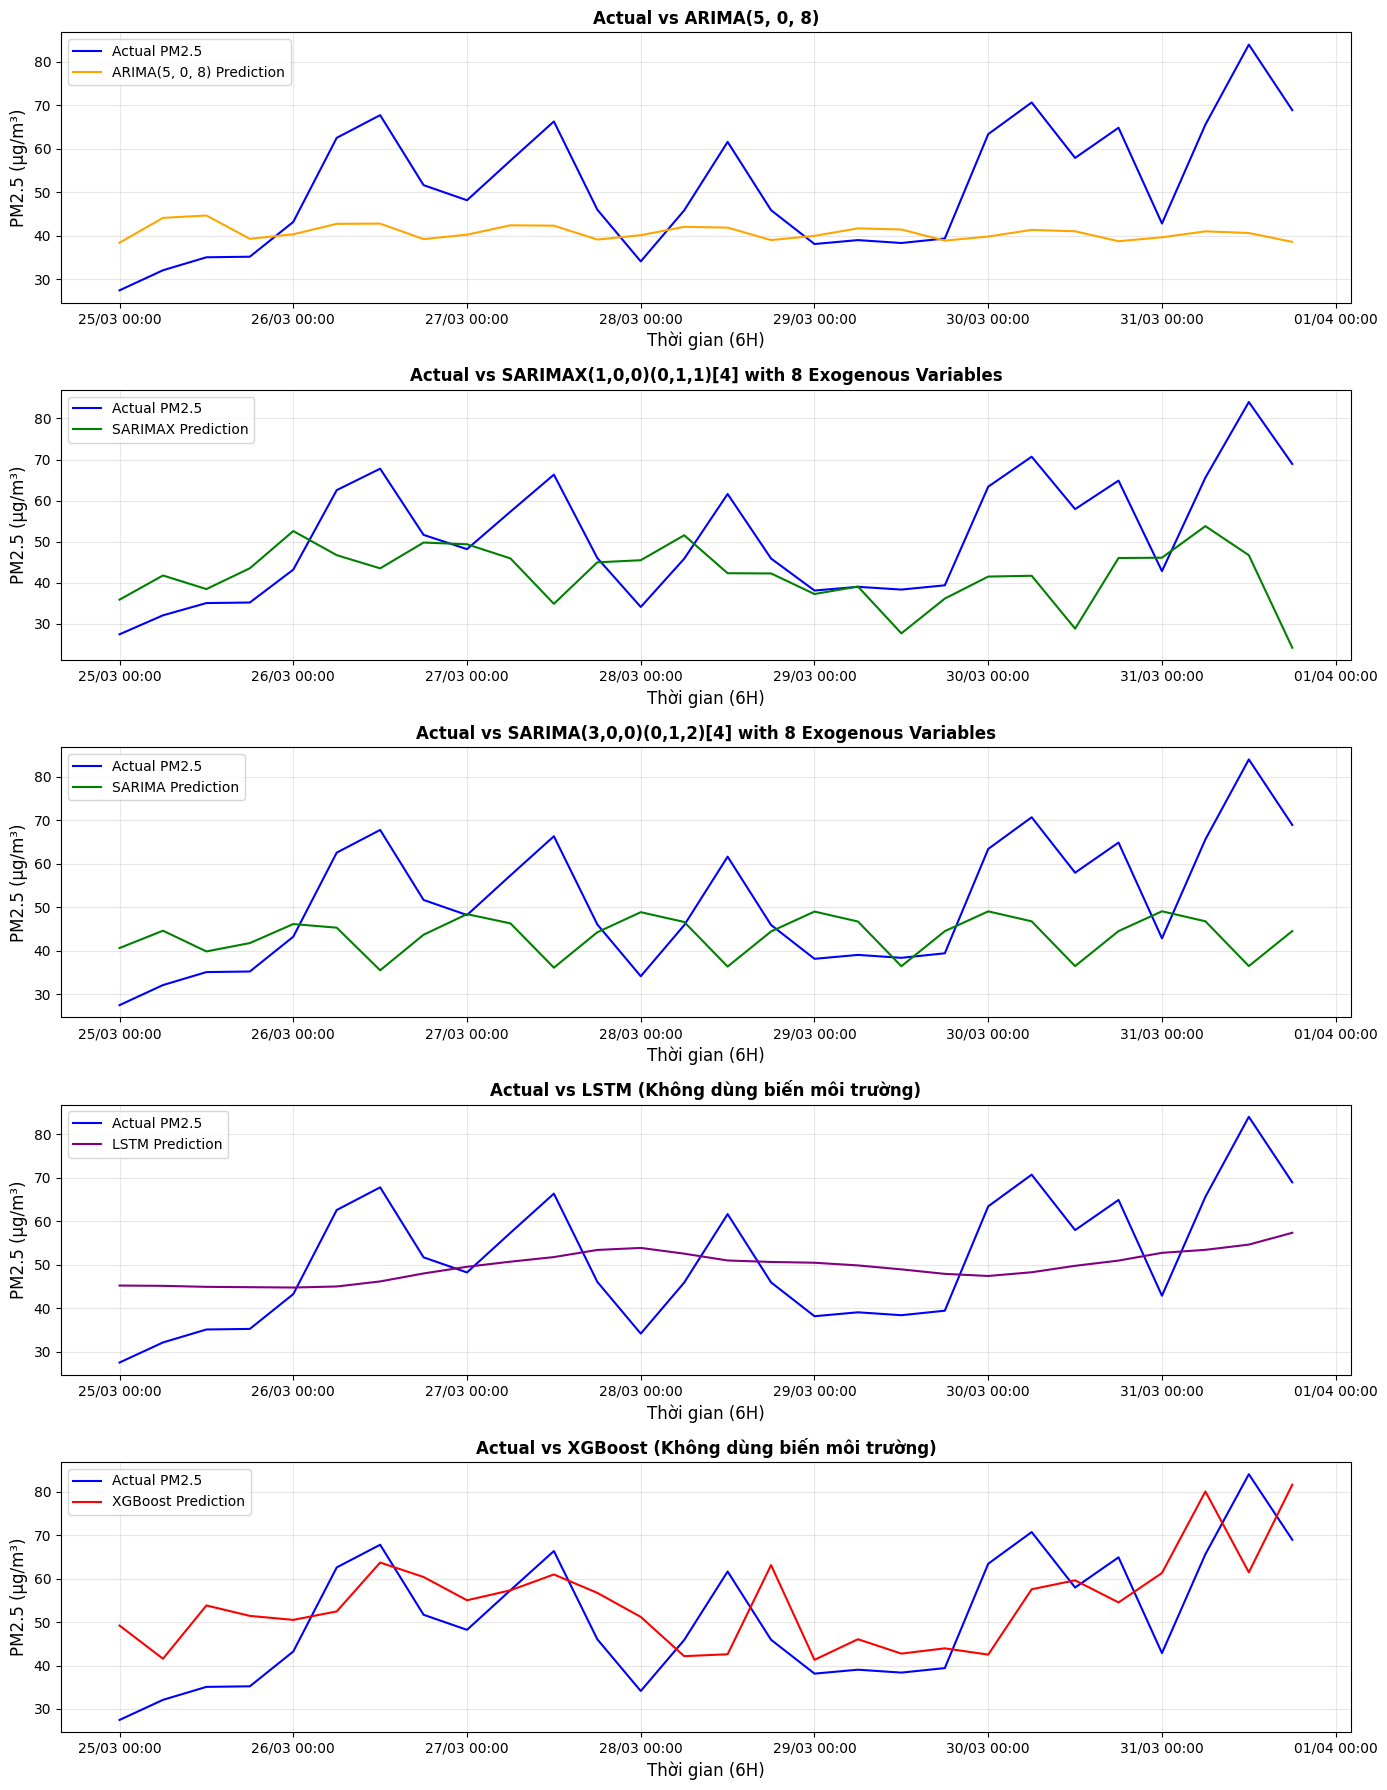

In [144]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ==============================================================================
# BƯỚC 1: TRÍCH XUẤT VÀ ÉP KIỂU DỮ LIỆU (CHỐNG LỖI MATPLOTLIB)
# ==============================================================================
# Trích xuất trục thời gian trực tiếp từ kết quả dự báo ARIMAX (đã là DatetimeIndex chuẩn)
time_index = forecast_arimax.index

# 1. Dữ liệu ARIMA(5, 0, 8) 
# Dùng endog_test_raw cho biến thực tế vì nó nguyên bản và không bị lỗi index
y_actual_arima = np.asarray(endog_test_raw, dtype=float).flatten()
y_pred_arima = np.asarray(arima_forecast, dtype=float).flatten()

# 2. Dữ liệu SARIMAX 
y_actual_arimax = np.asarray(endog_test_raw, dtype=float).flatten()
y_pred_arimax = np.asarray(forecast_arimax, dtype=float).flatten()

y_actual_sarima = np.asarray(endog_test_raw, dtype=float).flatten()
y_pred_sarima = np.asarray(sarima_forecast, dtype=float).flatten()

# 3. Dữ liệu XGBoost (Không môi trường)
y_actual_xgb = np.asarray(results_test['XGBoost_no_env_Final']['y_test'], dtype=float).flatten()
y_pred_xgb = np.asarray(results_test['XGBoost_no_env_Final']['y_pred'], dtype=float).flatten()

# 4. Dữ liệu LSTM (Có môi trường)
y_actual_lstm = np.asarray(results_test['LSTM_no_env_Final']['y_test'], dtype=float).flatten()
y_pred_lstm = np.asarray(results_test['LSTM_no_env_Final']['y_pred'], dtype=float).flatten()

# ==============================================================================
# BƯỚC 2: KHỞI TẠO FIGURE VÀ 4 SUBPLOTS THEO CHIỀU DỌC
# ==============================================================================
# Chỉnh nrows=4 và tăng chiều cao figsize lên 18 để các hình rộng rãi
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(14, 18))

# ==============================================================================
# BƯỚC 3: VẼ TỪNG ĐỒ THỊ
# ==============================================================================

# --- ĐỒ THỊ 1: ARIMA ---
axes[0].plot(time_index, y_actual_arima, color='blue', label='Actual PM2.5')
axes[0].plot(time_index, y_pred_arima, color='orange', label='ARIMA(5, 0, 8) Prediction')
axes[0].set_title("Actual vs ARIMA(5, 0, 8)", fontsize=12, fontweight='bold')
axes[0].set_ylabel('PM2.5 (µg/m³)')
axes[0].set_xlabel('Thời gian (6H)')
axes[0].legend(loc='upper left')

# --- ĐỒ THỊ 2: SARIMAX ---
axes[1].plot(time_index, y_actual_arimax, color='blue', label='Actual PM2.5')
axes[1].plot(time_index, y_pred_arimax, color='green', label='SARIMAX Prediction')
axes[1].set_title("Actual vs SARIMAX(1,0,0)(0,1,1)[4] with 8 Exogenous Variables", fontsize=12, fontweight='bold')
axes[1].set_ylabel('PM2.5 (µg/m³)')
axes[1].set_xlabel('Thời gian (6H)')
axes[1].legend(loc='upper left')

# --- ĐỒ THỊ 4: LSTM ---
axes[3].plot(time_index, y_actual_lstm, color='blue', label='Actual PM2.5')
axes[3].plot(time_index, y_pred_lstm, color='purple', label='LSTM Prediction') 
axes[3].set_title("Actual vs LSTM (Không dùng biến môi trường)", fontsize=12, fontweight='bold')
axes[3].set_ylabel('PM2.5 (µg/m³)')
axes[3].set_xlabel('Thời gian (6H)')
axes[3].legend(loc='upper left')

# --- ĐỒ THỊ 2: SARIMA ---
axes[2].plot(time_index, y_actual_sarima, color='blue', label='Actual PM2.5')
axes[2].plot(time_index, y_pred_sarima, color='green', label='SARIMA Prediction')
axes[2].set_title("Actual vs SARIMA(3,0,0)(0,1,2)[4] with 8 Exogenous Variables", fontsize=12, fontweight='bold')
axes[2].set_ylabel('PM2.5 (µg/m³)')
axes[2].set_xlabel('Thời gian (6H)')
axes[2].legend(loc='upper left')

# --- ĐỒ THỊ 3: XGBoost ---
axes[4].plot(time_index, y_actual_xgb, color='blue', label='Actual PM2.5')
axes[4].plot(time_index, y_pred_xgb, color='red', label='XGBoost Prediction')
axes[4].set_title("Actual vs XGBoost (Không dùng biến môi trường)", fontsize=12, fontweight='bold')
axes[4].set_ylabel('PM2.5 (µg/m³)')
axes[4].set_xlabel('Thời gian (6H)')
axes[4].legend(loc='upper left')

# ==============================================================================
# BƯỚC 4: TINH CHỈNH VÀ HIỂN THỊ TRỰC QUAN
# ==============================================================================
for ax in axes:
    # Dữ liệu 6H nên thêm %H:00 để thấy rõ các mốc 0h, 6h, 12h, 18h
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d/%m %H:00'))
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()